Loose detector

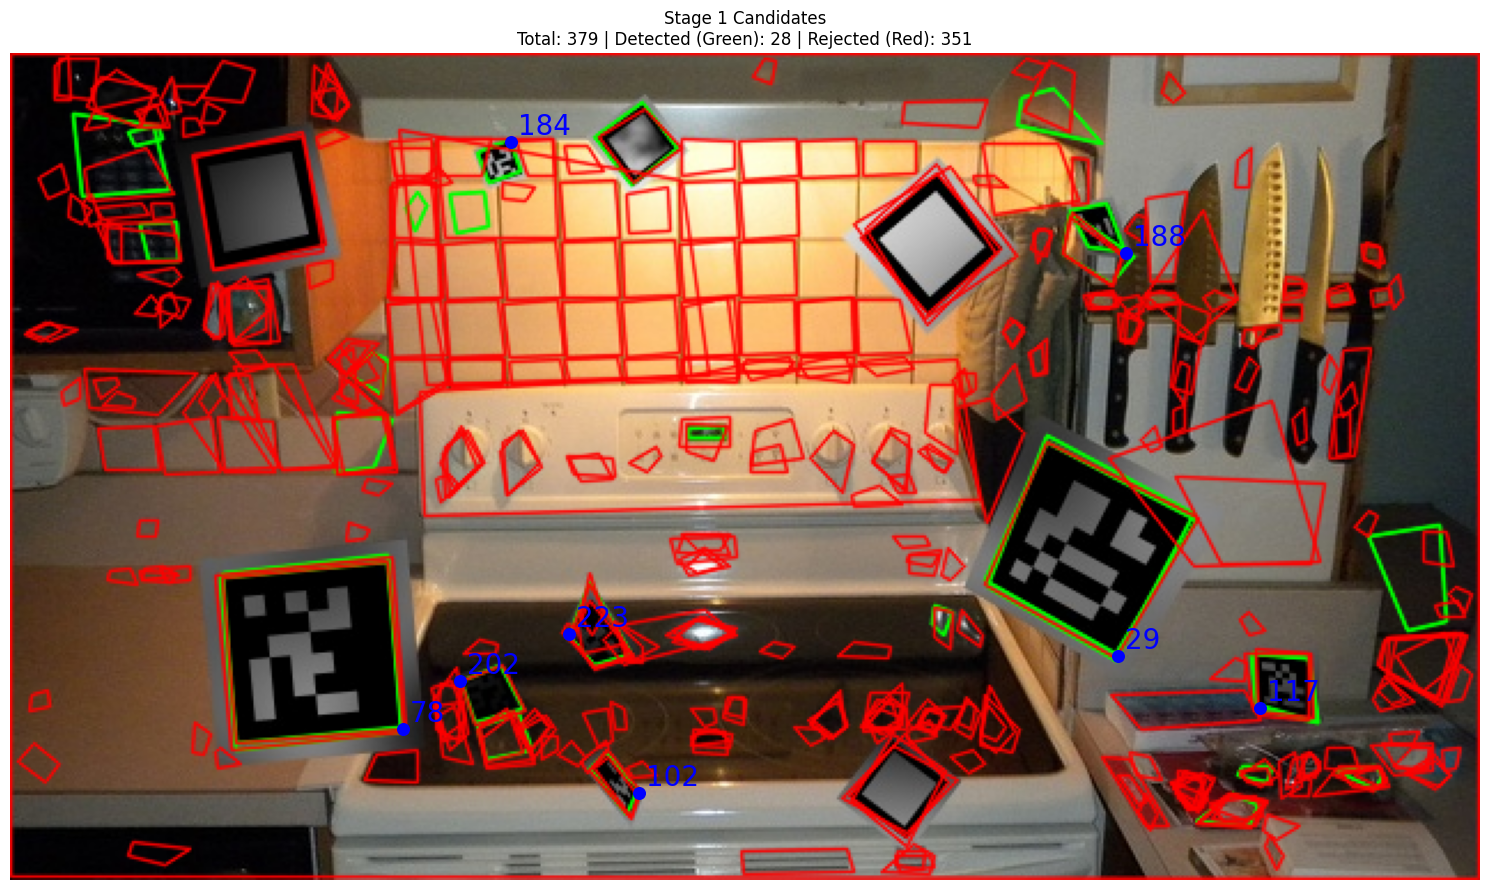

In [11]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd
import os
import sys

# Thiết lập thư mục gốc là /Users/nhatnam/Documents/CV_252/Assignment
# Lệnh này đảm bảo mọi code chạy dưới quyền thư mục Assignment
os.chdir("/Users/nhatnam/Documents/CV_252/Assignment")

# Thêm thư mục gốc vào sys.path để import được 'src'
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())


def visualize_stage1_candidates(csv_path, image_bgr, candidates, target_image_id,  figsize=(15, 10)):
    """
    Vẽ toàn bộ candidates tìm được lên ảnh gốc.
    - Màu Xanh lá (Detected): OpenCV nhận diện được mã.
    - Màu Đỏ (Rejected): Vùng tiềm năng nhưng không giải mã được.
    """
    
    df = pd.read_csv(csv_path)
    cf = pd.read_csv(csv_path, dtype={"image_id": str})

    # Tìm dòng tương ứng
    row = df[cf["image_id"] == target_image_id]

    if row.empty:
        print(f"Không tìm thấy image_id = {target_image_id}")
        return

    prediction_string = row.iloc[0]["prediction_string"]

    if pd.isna(prediction_string) or prediction_string.strip() == "":
        print("prediction_string rỗng")
        return

    # Parse prediction_string
    values = prediction_string.strip().split()

    if len(values) % 3 != 0:
        print("prediction_string không đúng format id x y")
        return

    points = []

    for i in range(0, len(values), 3):
        class_id = int(values[i])
        x = float(values[i + 1])
        y = float(values[i + 2])

        points.append((class_id, x, y))


    vis_img = image_bgr.copy()
    num_detected = 0
    num_rejected = 0
    
    for cand in candidates:
        # Chuyển corners sang định dạng int để vẽ
        pts = np.int32(cand["corners"]).reshape((-1, 1, 2))
        
        # Phân loại để chọn màu và độ dày
        if cand.get("type") == "detected":
            color = (0, 255, 0)  # Xanh lá
            thickness = 1
            num_detected += 1
            # Vẽ đa giác bao quanh candidate
            cv2.polylines(vis_img, [pts], isClosed=True, color=color, thickness=thickness, lineType=cv2.LINE_AA)
            
            # Vẽ một chấm nhỏ tại góc đầu tiên (Top-Left) để xác định định hướng
            top_left = tuple(pts[0][0])
            #cv2.circle(vis_img, top_left, 4, (255, 255, 255), -1) # Chấm trắng nhỏ làm tâm
            #cv2.circle(vis_img, top_left, 2, color, -1)           # Chấm màu theo loại
        else:
            color = (0, 0, 255)  # Đỏ
            thickness = 1
            num_rejected += 1
            
        cv2.polylines(vis_img, [pts], isClosed=True, color=color, thickness=thickness, lineType=cv2.LINE_AA)
        
    # Chuyển màu để hiển thị đúng trên Matplotlib
    vis_rgb = cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=figsize)
    plt.imshow(vis_rgb)
    
    # Tiêu đề chi tiết để debug
    plt.title(f"Stage 1 Candidates\n"
              f"Total: {len(candidates)} | "
              f"Detected (Green): {num_detected} | "
              f"Rejected (Red): {num_rejected}")
    
    for class_id, x, y in points:
        plt.scatter(x, y, s=70, color='blue')
        plt.text(
            x + 3,
            y - 3,
            str(class_id),
            fontsize=20,
            color='blue'
        )
    
    plt.axis("off")
    plt.tight_layout()
    plt.show()


from src.preprocess import generate_augmented_images
from src.detector import extract_candidates, filter_and_cluster_candidates

img = cv2.imread("data/aruco_data/train/000000000089.jpg")
img_name = "000000000089"
aug_dict = generate_augmented_images(img)
candidates = extract_candidates(img, aug_dict)
final_can = filter_and_cluster_candidates(candidates)
visualize_stage1_candidates("data/train.csv", img, final_can, img_name)

Augmentation

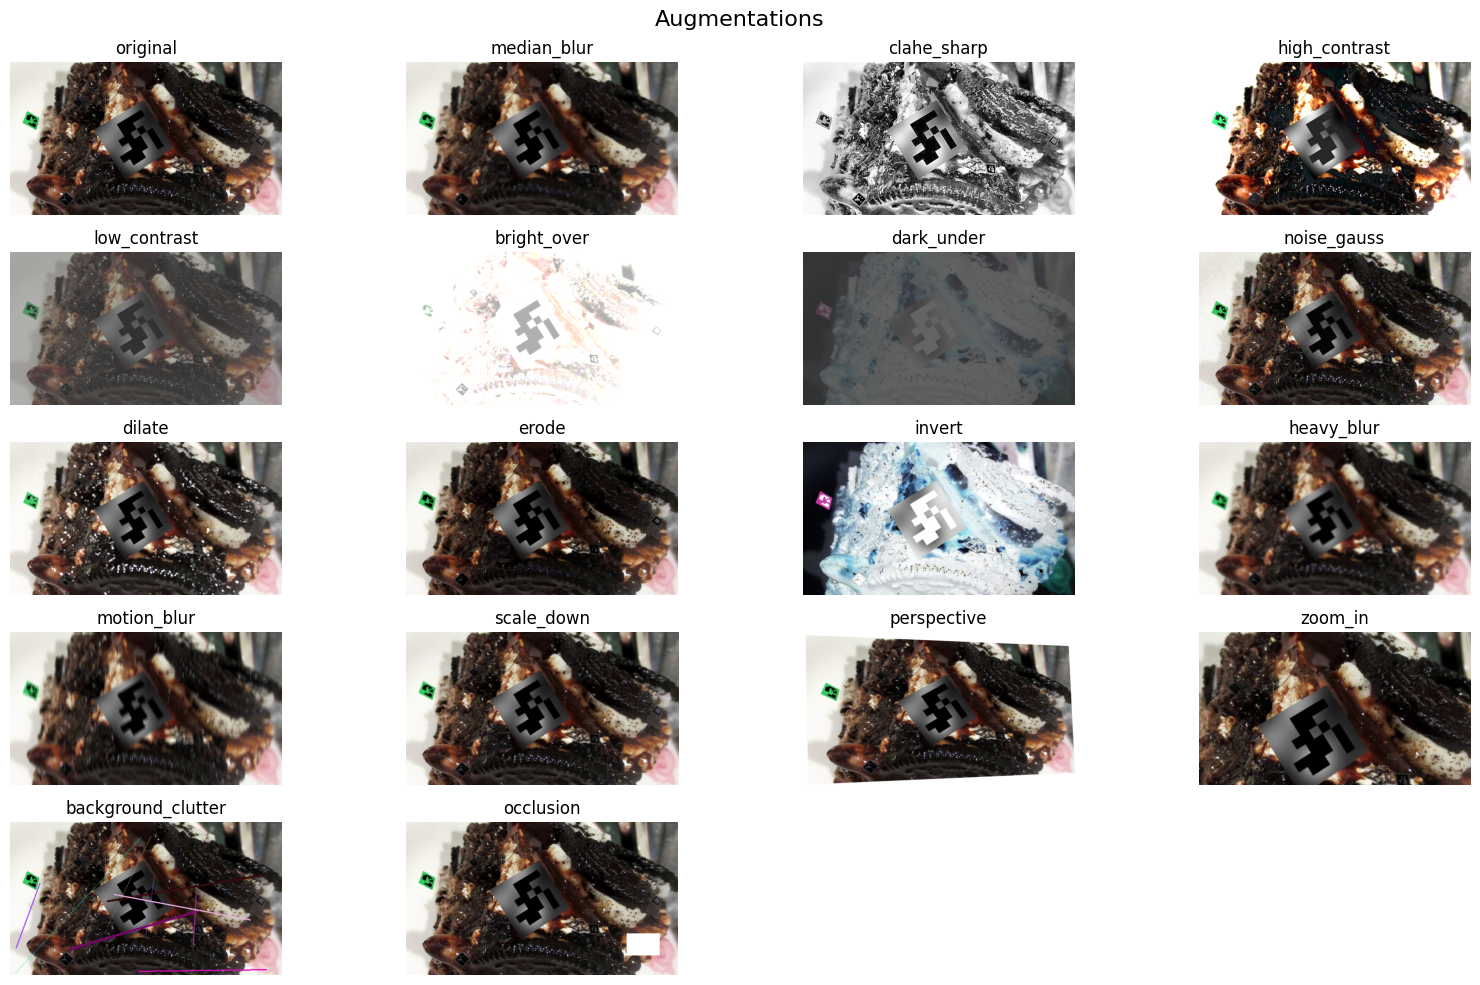

In [2]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def extract_image(v):
    """
    Extract numpy image from unknown dict structure
    """

    if isinstance(v, np.ndarray):
        return v

    if isinstance(v, dict):
        # thử các key phổ biến nhất
        for key in ["image", "img", "output", "result", "data"]:
            if key in v and isinstance(v[key], np.ndarray):
                return v[key]

        # fallback: tìm value đầu tiên là image
        for val in v.values():
            if isinstance(val, np.ndarray):
                return val

    return None

def visualize_augmentations(aug_dict, cols=4, figsize=(16, 10), title="Augmentations"):
    keys = list(aug_dict.keys())
    n = len(keys)
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=figsize)
    plt.suptitle(title, fontsize=16)

    for i, k in enumerate(keys):
        raw = aug_dict[k]
        img = extract_image(raw)

        if img is None:
            print(f"[SKIP] {k}: cannot extract image")
            continue

        # convert BGR → RGB nếu cần
        if len(img.shape) == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
        plt.title(k)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    
from src.preprocess import generate_augmented_images

img = cv2.imread("data/aruco_data/train/000000022087.jpg")
aug_dict = generate_augmented_images(img)

visualize_augmentations(aug_dict, cols=4)

Test CNN

Loaded CNN model from: models/aruco_classifier_model_epoch50.keras


I0000 00:00:1779639709.660944 3394746 service.cc:153] XLA service 0x1290fa3a0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779639709.660961 3394746 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1779639709.670230 3394746 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1779639709.785080 3394816 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
I0000 00:00:1779639709.785266 3394816 rsqrt.cc:179] Falling back to 1 / sqrt(x) for f32 false
I0000 00:00:1779639709.818615 3394746 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


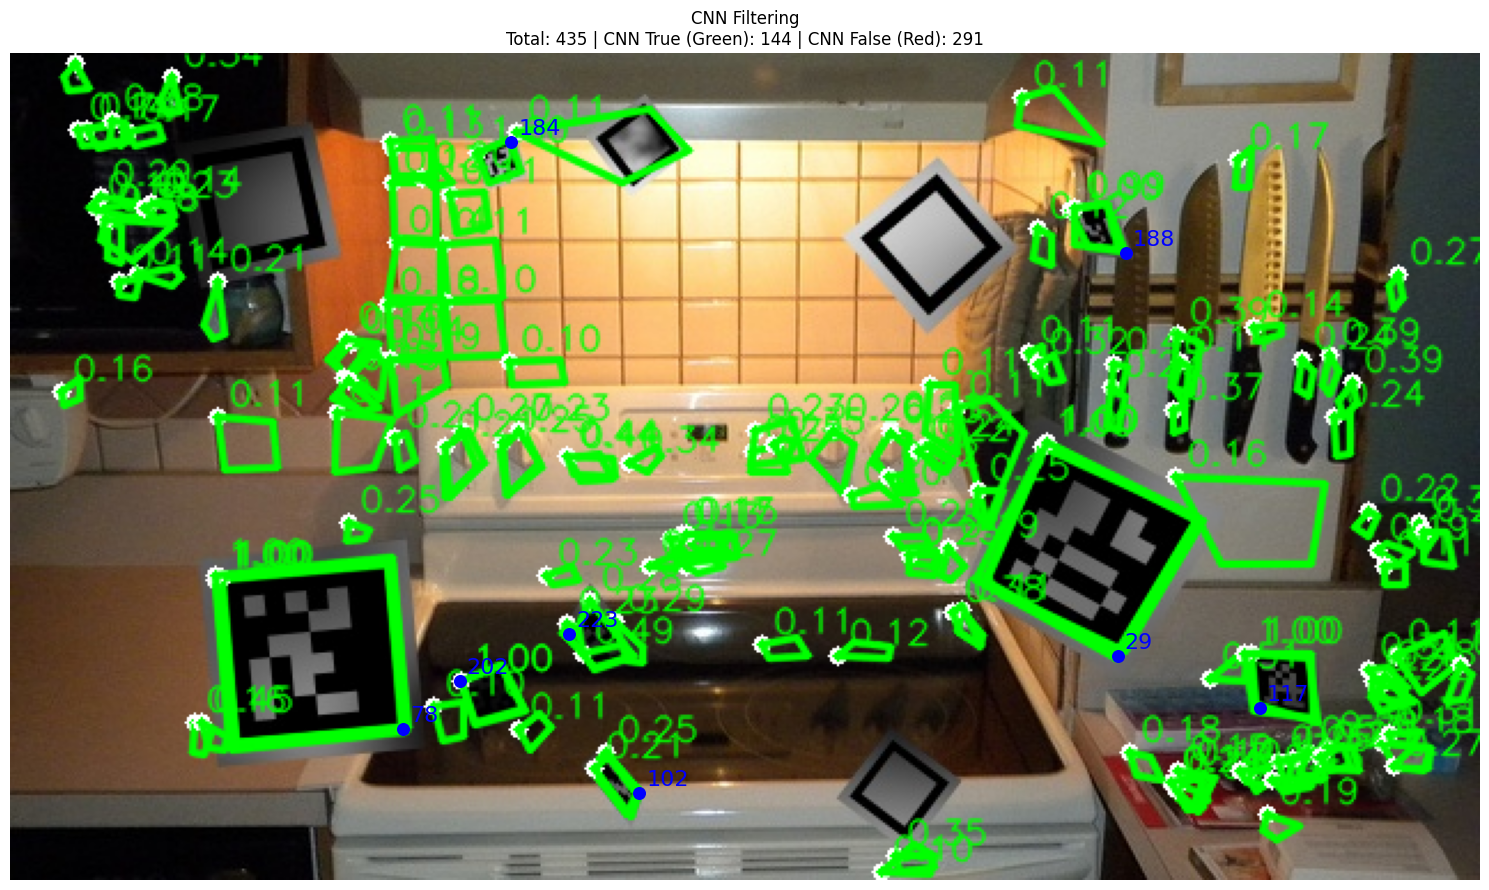

In [3]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd

from src.postprocess import (
    load_cnn_model,
    is_real_marker_consistent,
    order_corners
)


def visualize_cnn_true_candidates(
    csv_path,
    image_bgr,
    candidates,
    target_image_id,
    model_path="aruco_classifier_model.keras",
    threshold=0.5,
    figsize=(15, 10)
):
    """
    Visualize candidate sau khi đi qua CNN

    Green = CNN predict TRUE (real marker)
    Red   = CNN predict FALSE (fake marker)

    Blue  = Ground truth từ train.csv
    """
    model = load_cnn_model(model_path)
    
    df = pd.read_csv(csv_path)
    cf = pd.read_csv(csv_path, dtype={"image_id": str})
    
    row = df[cf["image_id"] == target_image_id]
    
    if row.empty:
        print(f"Không tìm thấy image_id = {target_image_id}")
        return
    
    prediction_string = row.iloc[0]["prediction_string"]

    points = []

    if not pd.isna(prediction_string) and prediction_string.strip() != "":
        values = prediction_string.strip().split()

        if len(values) % 3 != 0:
            print("prediction_string không đúng format id x y")
            return

        for i in range(0, len(values), 3):
            class_id = int(values[i])
            x = float(values[i + 1])
            y = float(values[i + 2])

            points.append((class_id, x, y))
            
            
    vis_img = image_bgr.copy()

    num_true = 0
    num_false = 0

    for cand in candidates:
        corners = cand["corners"]

        # dùng trực tiếp hàm từ postprocess.py
        is_real, prob = is_real_marker_consistent(
            model,
            image_bgr,
            cand,
            threshold=threshold
        )

        pts = np.int32(corners).reshape((-1, 1, 2))

        if is_real:
            color = (0, 255, 0)   # Green
            thickness = 2
            num_true += 1

            ordered = order_corners(corners)
            top_left = tuple(np.int32(ordered[0]))

            # đánh dấu top-left
            cv2.circle(vis_img, top_left, 4, (255, 255, 255), -1)
            cv2.circle(vis_img, top_left, 2, color, -1)

            # hiển thị xác suất CNN
            cv2.putText(
                vis_img,
                f"{prob:.2f}",
                (top_left[0] + 5, top_left[1] - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                color,
                1,
                cv2.LINE_AA
            )
            cv2.polylines(
                vis_img,
                [pts],
                isClosed=True,
                color=color,
                thickness=thickness,
                lineType=cv2.LINE_AA
            )

        else:
            color = (0, 0, 255)   # Red
            thickness = 1
            num_false += 1

        
        
    vis_rgb = cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=figsize)
    plt.imshow(vis_rgb)

    plt.title(
        f"CNN Filtering\n"
        f"Total: {len(candidates)} | "
        f"CNN True (Green): {num_true} | "
        f"CNN False (Red): {num_false}"
    )


    for class_id, x, y in points:
        plt.scatter(x, y, s=70, color="blue")
        plt.text(
            x + 3,
            y - 3,
            str(class_id),
            fontsize=16,
            color="blue"
        )

    plt.axis("off")
    plt.tight_layout()
    plt.show()
    
from src.preprocess import generate_augmented_images
from src.detector import extract_candidates, filter_and_cluster_candidates

img = cv2.imread("data/aruco_data/train/000000000089.jpg")
img_name = "000000000089"

aug_dict = generate_augmented_images(img)
candidates = extract_candidates(img, aug_dict)
final_can = filter_and_cluster_candidates(candidates)

visualize_cnn_true_candidates(
    csv_path="data/train.csv",
    image_bgr=img,
    candidates=final_can,
    target_image_id=img_name,
    model_path="models/aruco_classifier_model_epoch50.keras",
    threshold=0.1
)

Test Stage 3 of Pipeline

Loaded CNN model from: models/aruco_classifier_model_epoch50.keras
Total final candidates: 469
Candidates near (273.434, 321.559) = 1

Candidate #1
source = low_contrast
mapped top-left = [273.5151  320.73874]
raw top-left    = [273.5151  320.73874]
CNN prob = 0.2513 | is_real = True
ROI shape = (48, 42, 3)
offset = (242, 294)


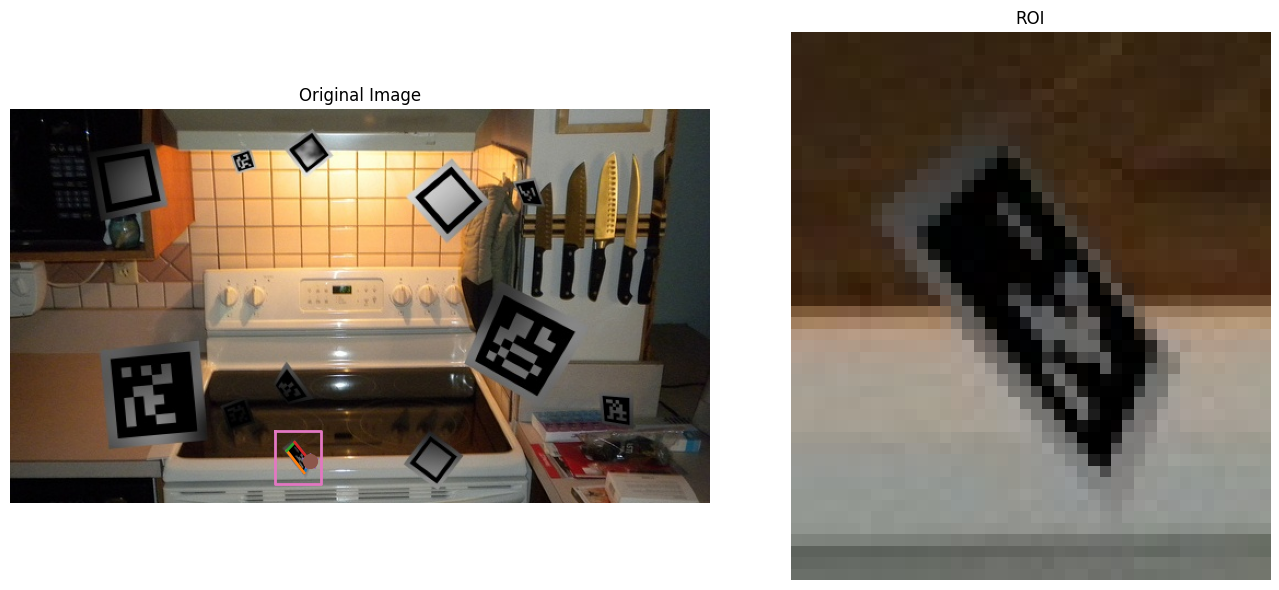

[1] original | shape=(48, 42, 3) | success=False


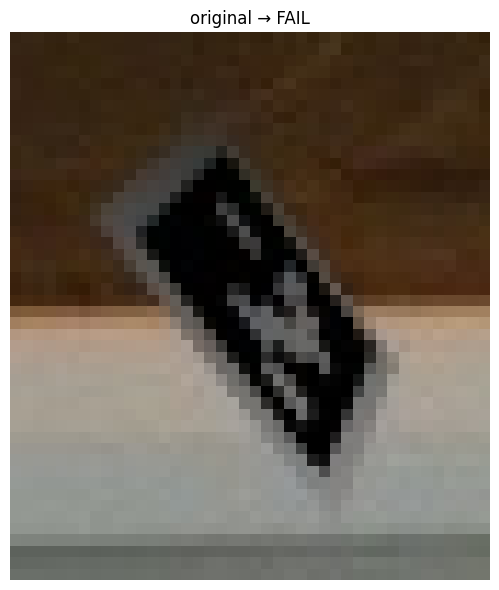

[2] upscale_2x | shape=(96, 84, 3) | success=True
FINAL DETECT SUCCESS from variant: upscale_2x


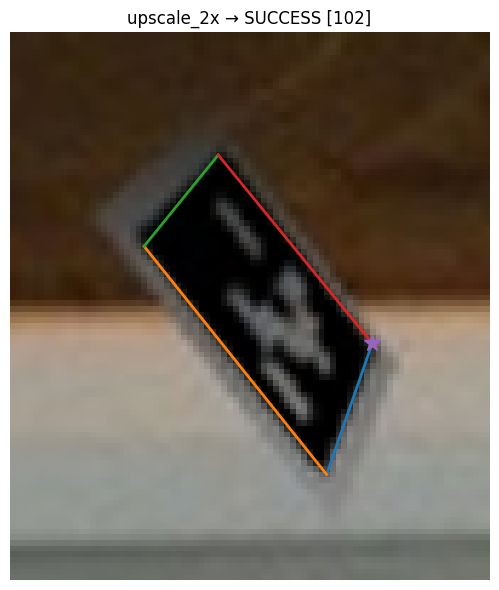

[3] upscale_3x | shape=(240, 210, 3) | success=True


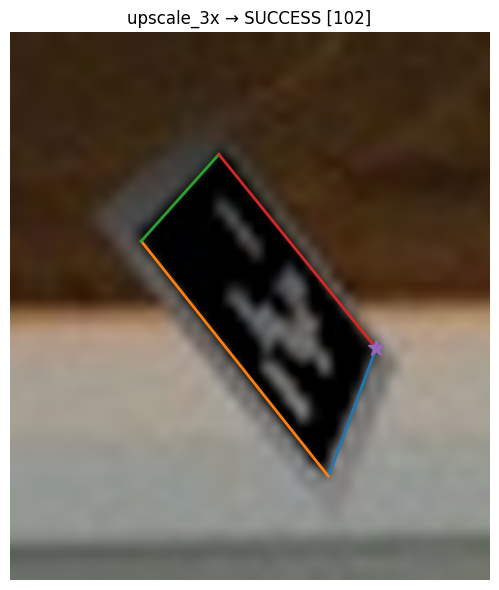

[4] median_blur_3 | shape=(48, 42, 3) | success=False


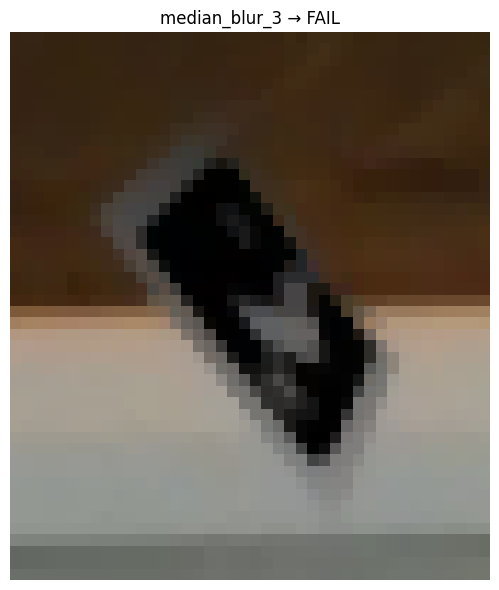

[5] median_blur_2x_3 | shape=(96, 84, 3) | success=True


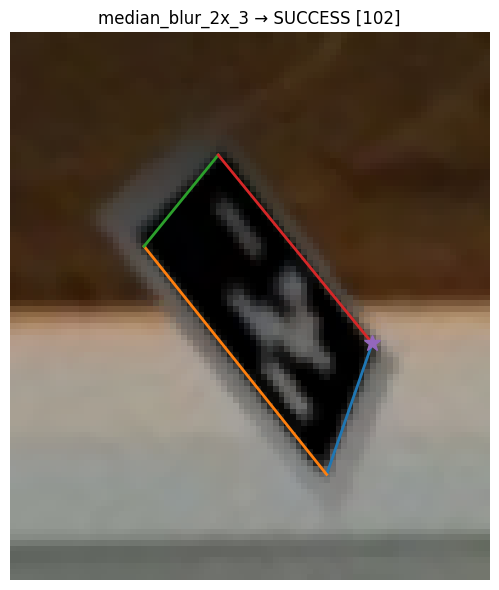

[6] median_blur_2x_5 | shape=(96, 84, 3) | success=True


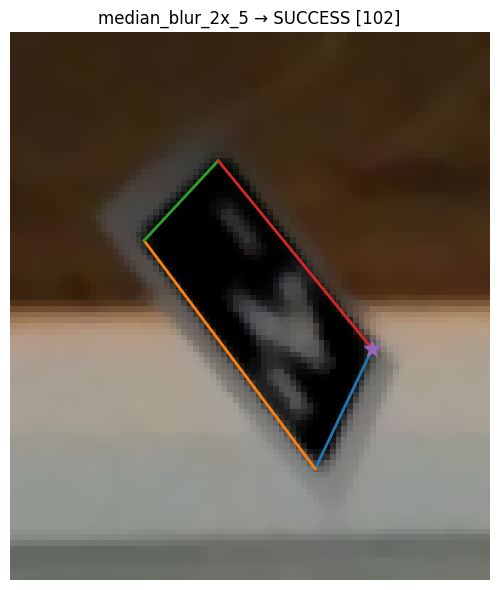

[7] median_blur_3x_3 | shape=(240, 210, 3) | success=True


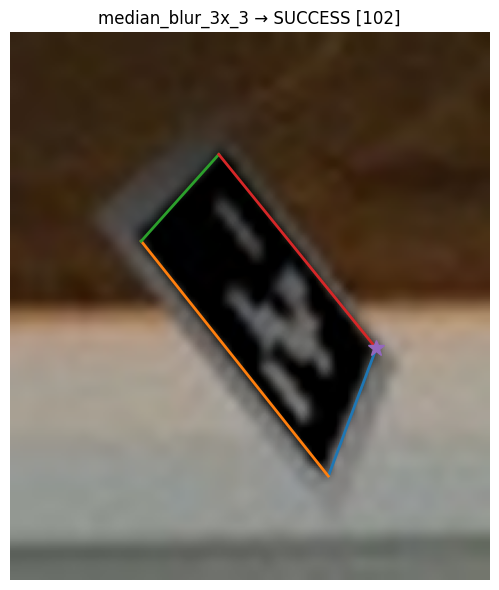

[8] gaussian_blur_2x_3 | shape=(96, 84, 3) | success=True


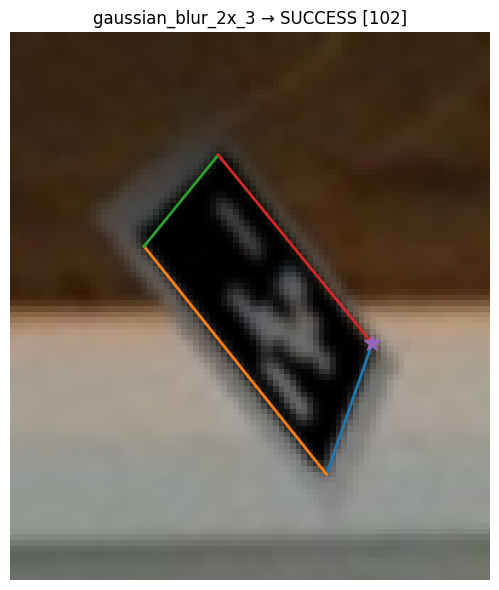

[9] bilateral_bgr | shape=(48, 42, 3) | success=False


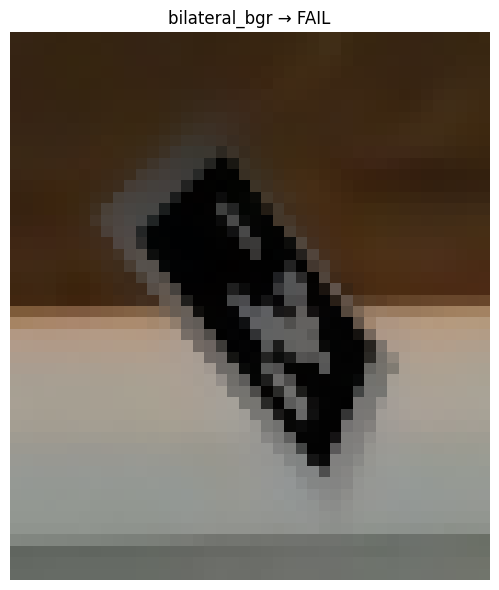

[10] bilateral_2x | shape=(96, 84, 3) | success=True


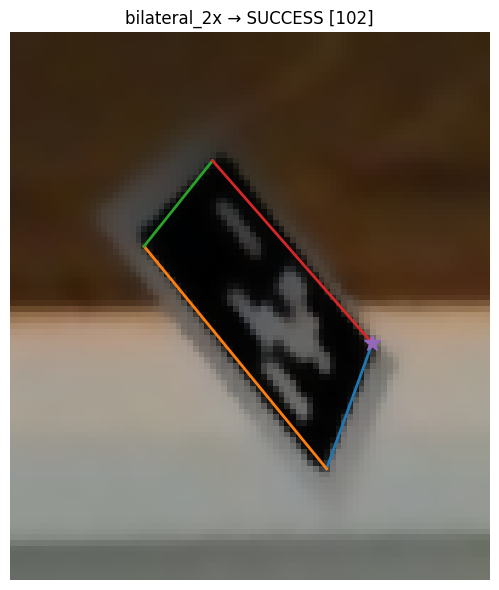

[11] clahe_gamma_sharp | shape=(48, 42, 3) | success=False


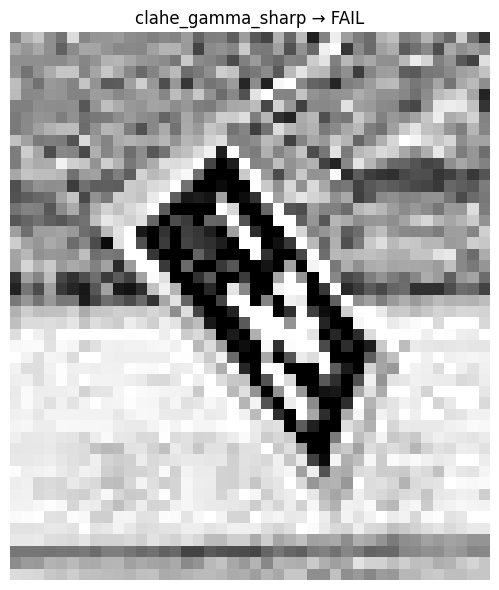

[12] gamma_2 | shape=(48, 42, 3) | success=False


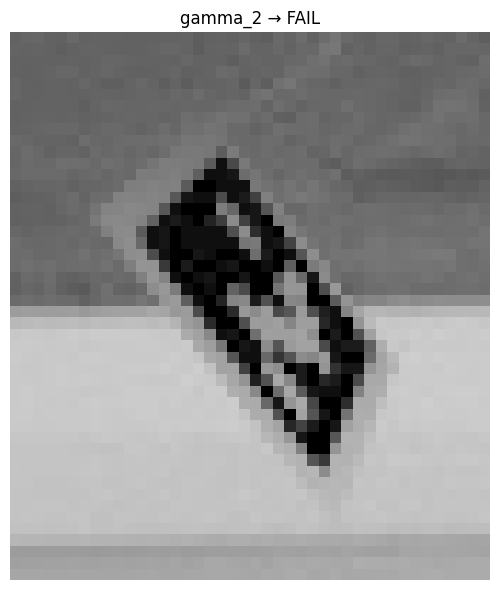

[13] gamma_3 | shape=(48, 42, 3) | success=False


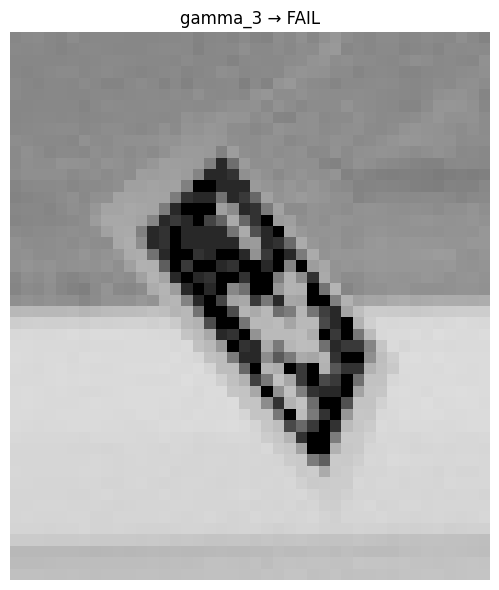

[14] gamma_2x_2 | shape=(96, 84, 3) | success=True


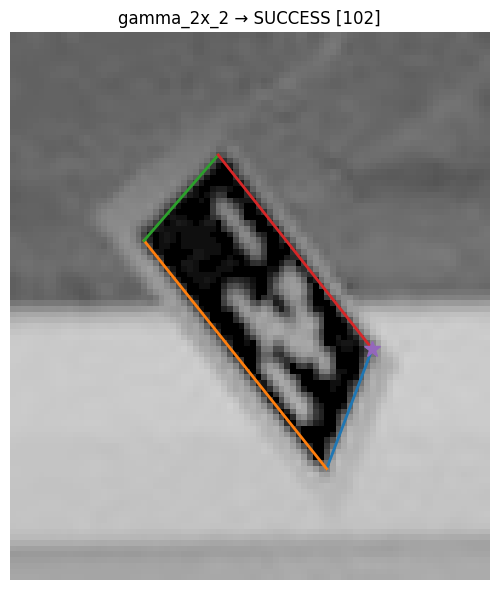

[15] gamma_2x_3 | shape=(96, 84, 3) | success=False


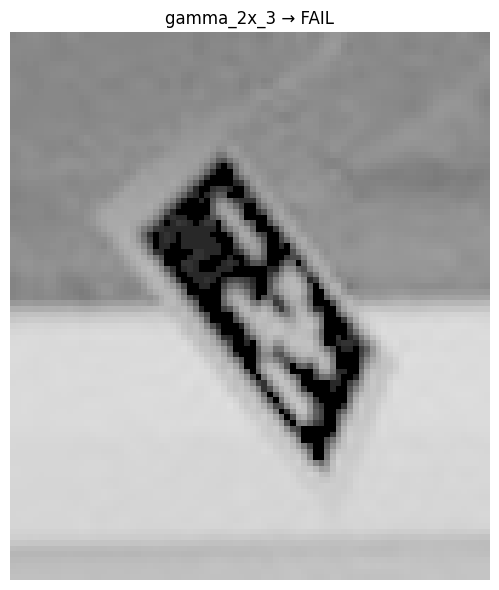

[16] bright_a2_b30 | shape=(48, 42, 3) | success=False


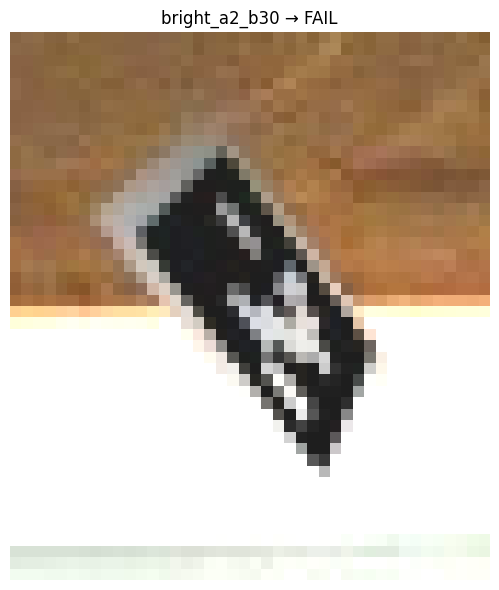

[17] bright_a25_b50 | shape=(48, 42, 3) | success=False


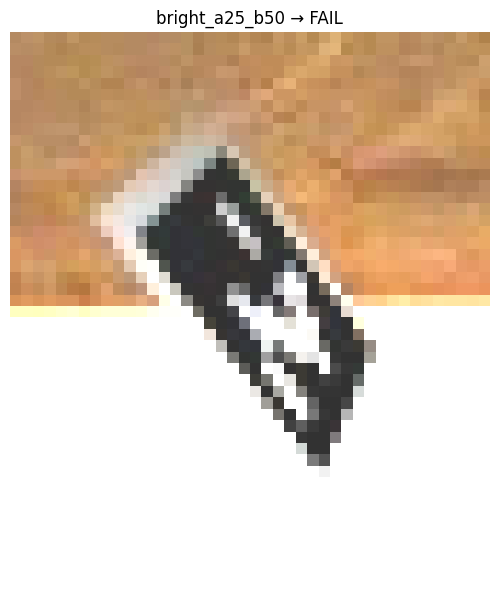

[18] bright_a3_b80 | shape=(48, 42, 3) | success=False


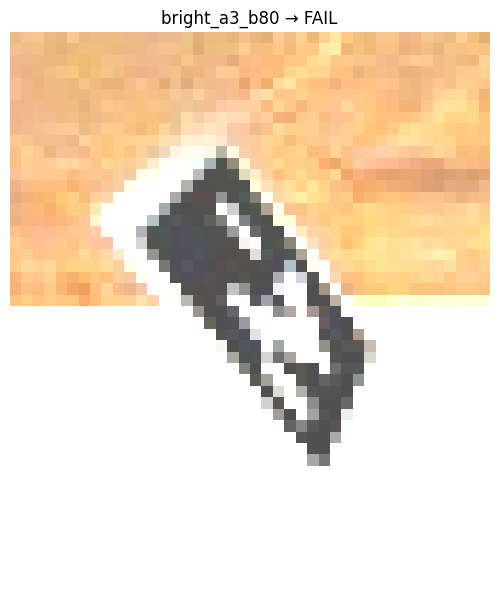

[19] bright_2x_a2_b30 | shape=(96, 84, 3) | success=True


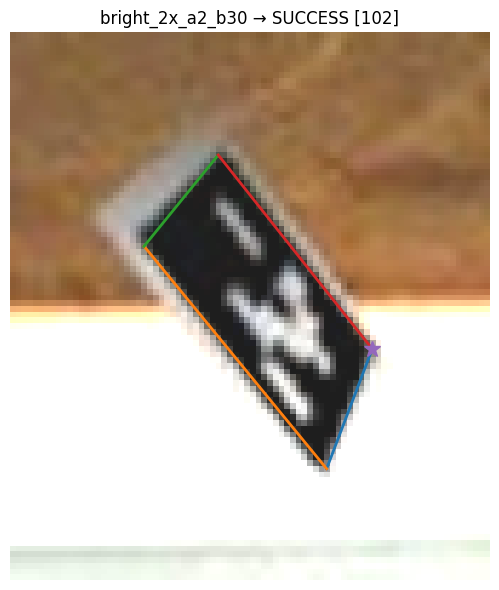

[20] bright_2x_a25_b50 | shape=(96, 84, 3) | success=True


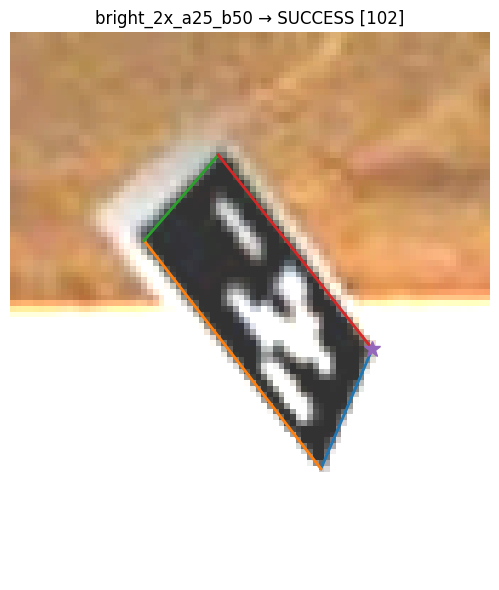

[21] bright_2x_a3_b80 | shape=(96, 84, 3) | success=True


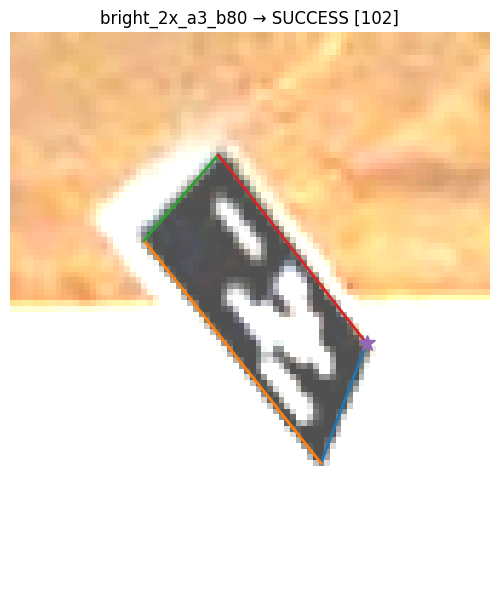

[22] clahe_4_8 | shape=(48, 42, 3) | success=False


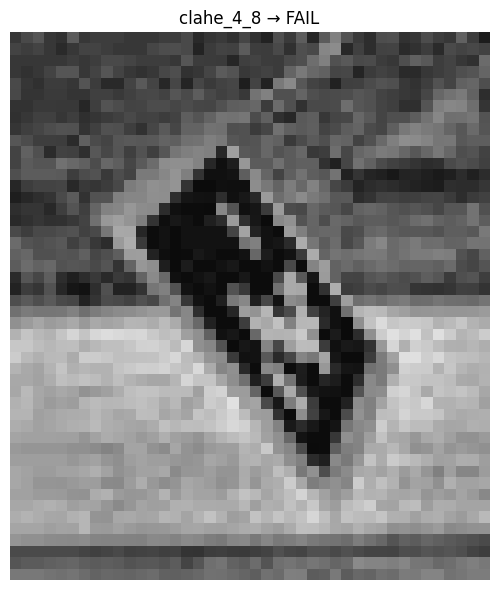

[23] clahe_8_4 | shape=(48, 42, 3) | success=False


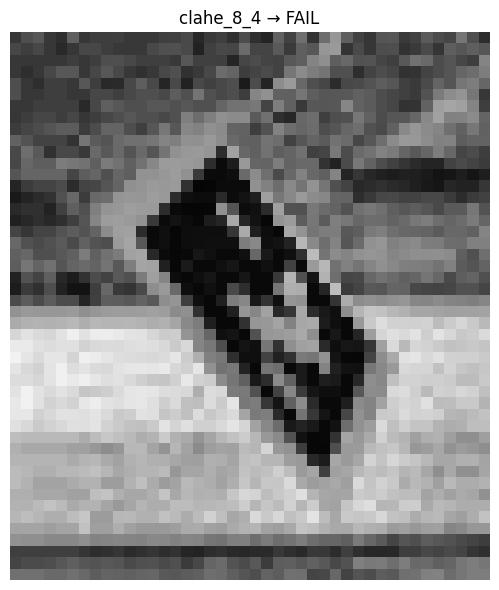

[24] clahe_12_2 | shape=(48, 42, 3) | success=False


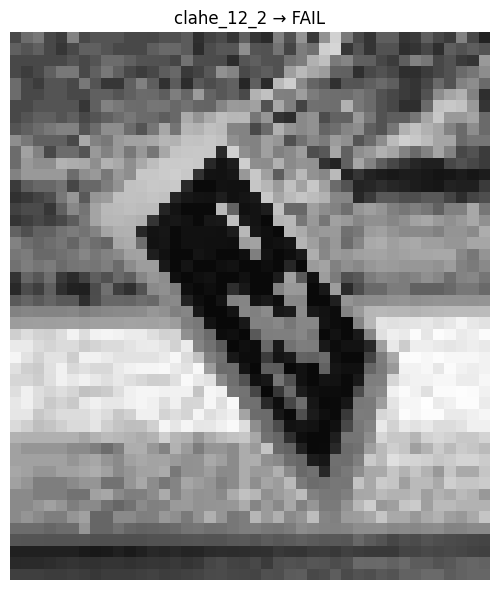

[25] clahe_2x_4_8 | shape=(96, 84, 3) | success=True


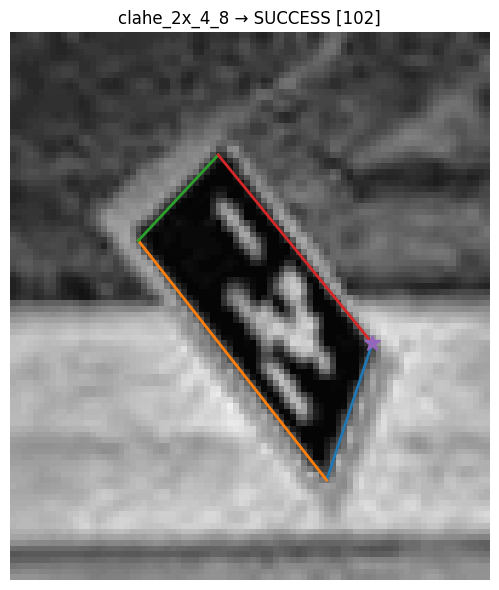

[26] clahe_2x_8_4 | shape=(96, 84, 3) | success=True


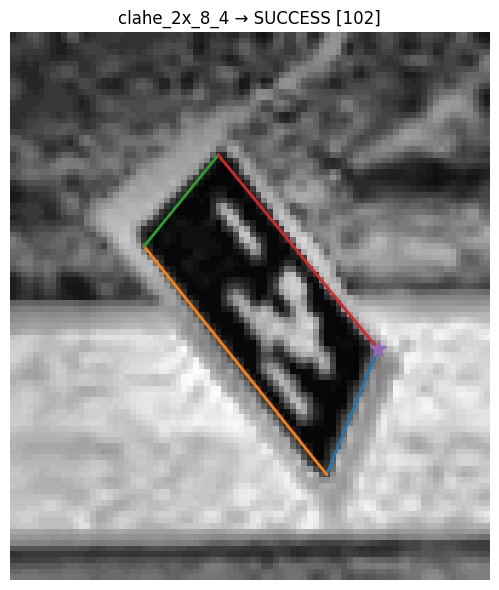

[27] equalize | shape=(48, 42, 3) | success=False


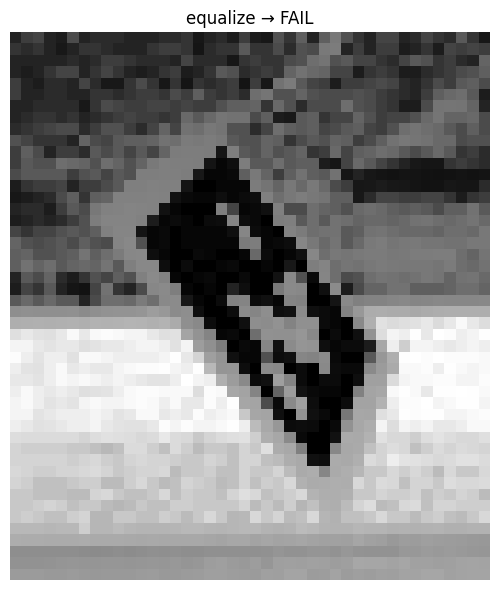

[28] equalize_2x | shape=(96, 84, 3) | success=True


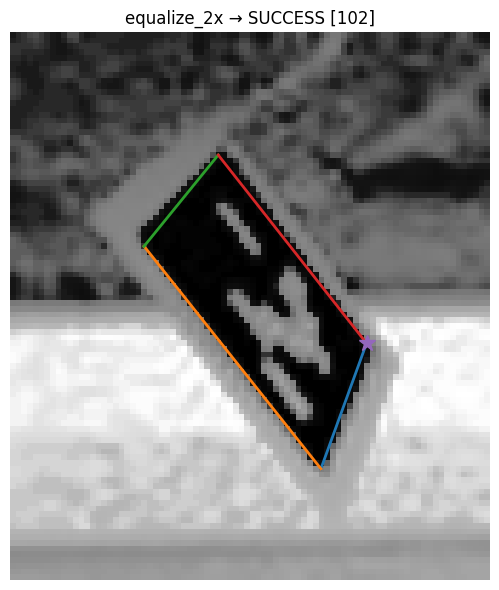

[29] clahe_gamma | shape=(48, 42, 3) | success=False


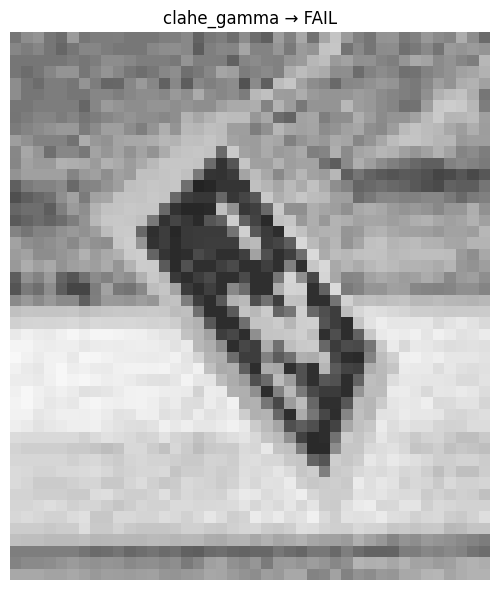

[30] clahe_gamma_2x | shape=(96, 84, 3) | success=True


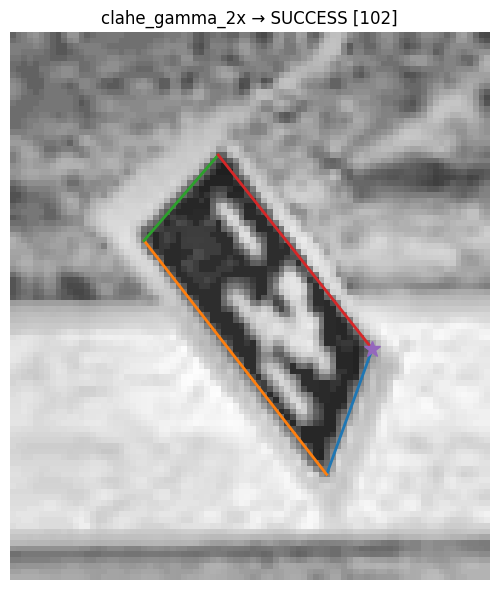

[31] dark_a04_b30 | shape=(48, 42, 3) | success=False


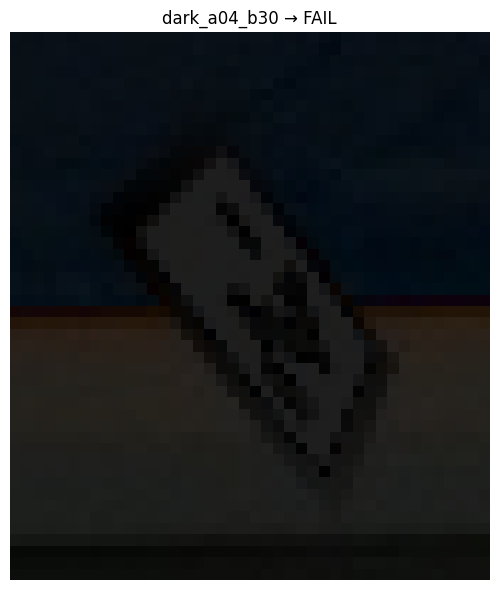

[32] dark_a05_b50 | shape=(48, 42, 3) | success=False


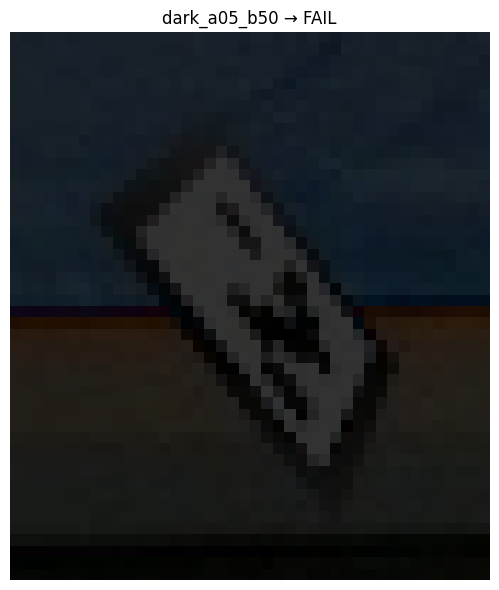

[33] dark_a06_b20 | shape=(48, 42, 3) | success=False


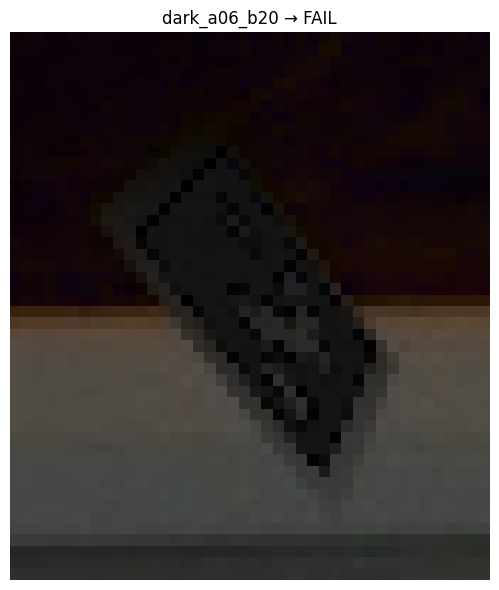

[34] dark_2x_a04_b30 | shape=(96, 84, 3) | success=False


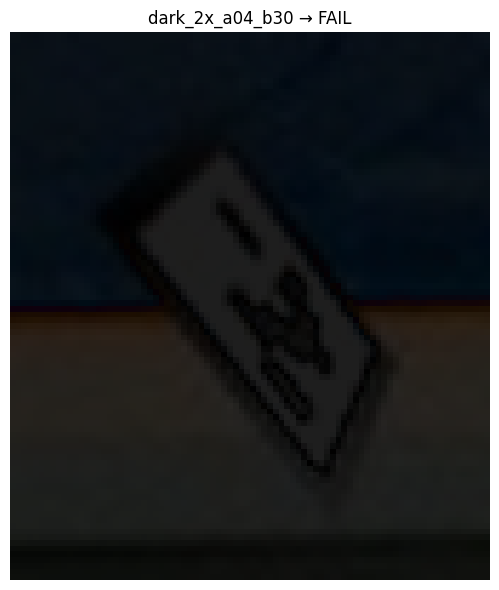

[35] dark_2x_a05_b50 | shape=(96, 84, 3) | success=False


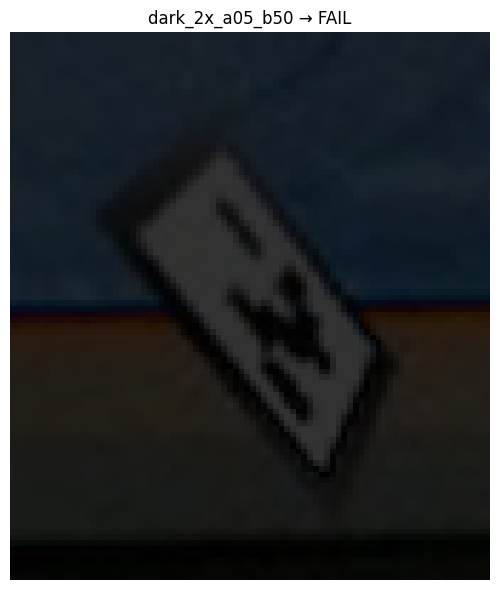

[36] gamma_light_05 | shape=(48, 42, 3) | success=False


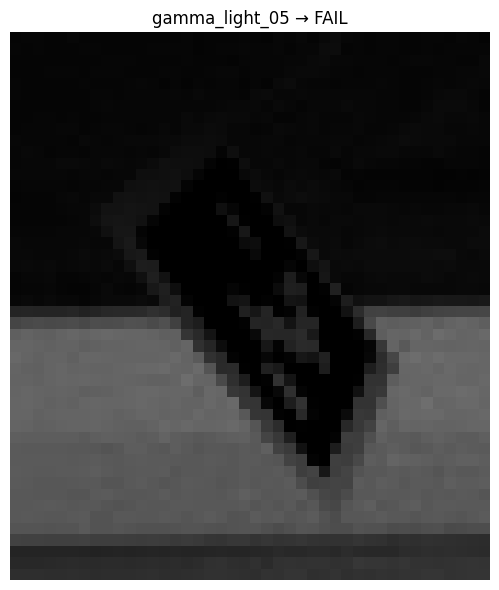

[37] gamma_light_04 | shape=(48, 42, 3) | success=False


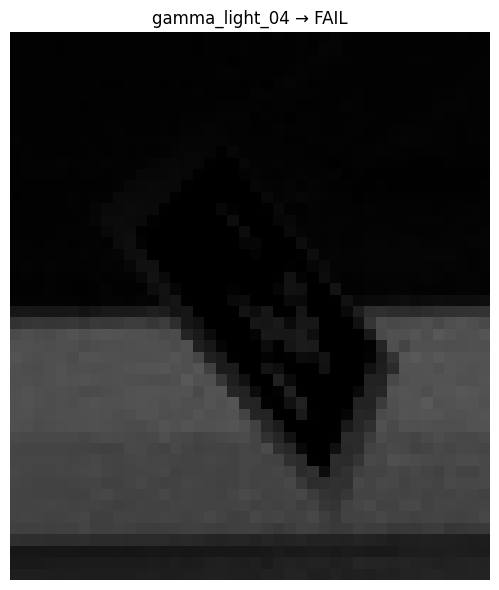

[38] gamma_light_2x_05 | shape=(96, 84, 3) | success=False


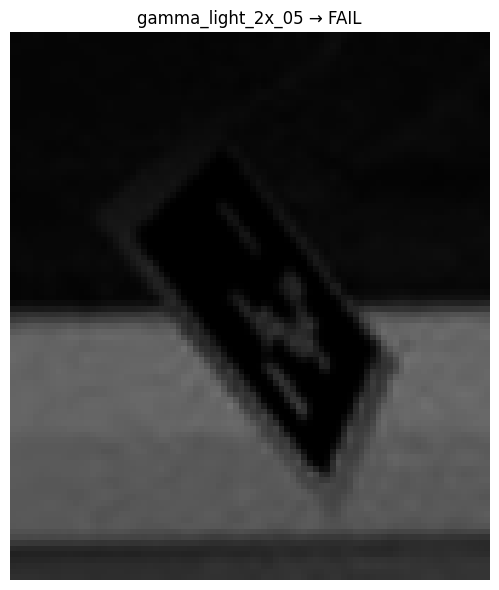

[39] otsu | shape=(48, 42, 3) | success=False


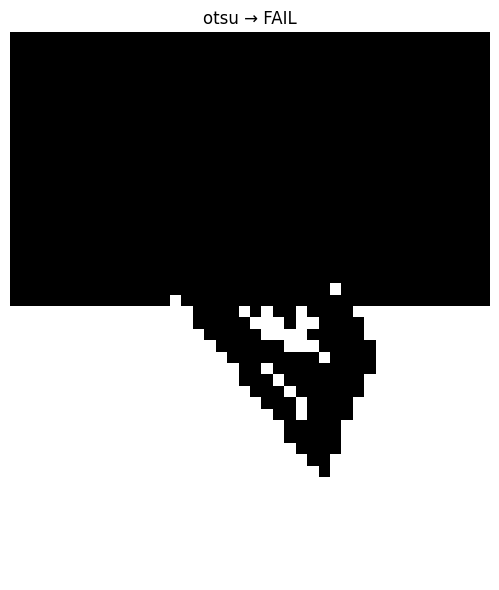

[40] otsu_2x | shape=(96, 84, 3) | success=False


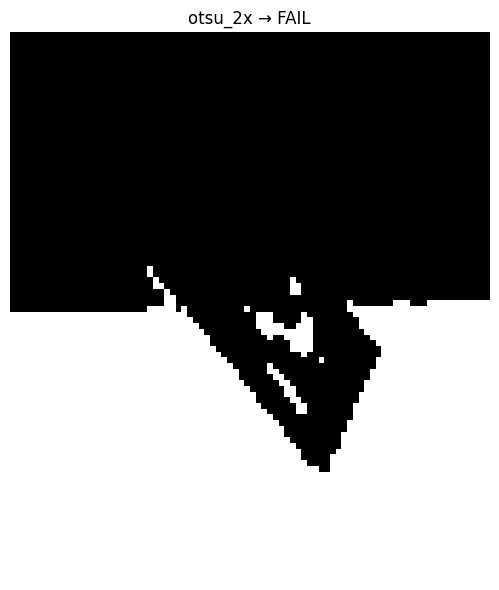

[41] otsu_3x | shape=(240, 210, 3) | success=False


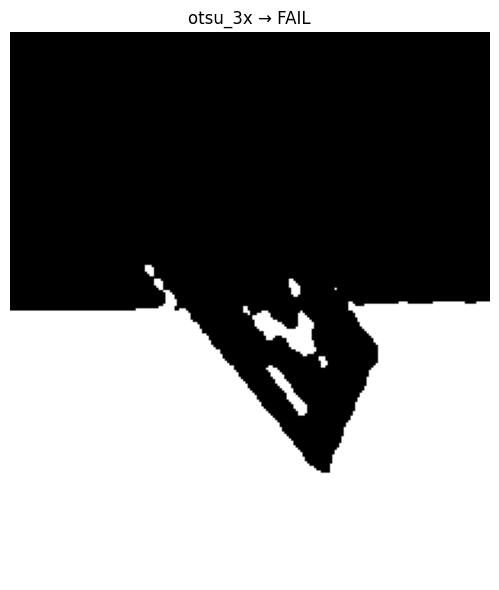

[42] adaptive_gaussian_7 | shape=(48, 42, 3) | success=False


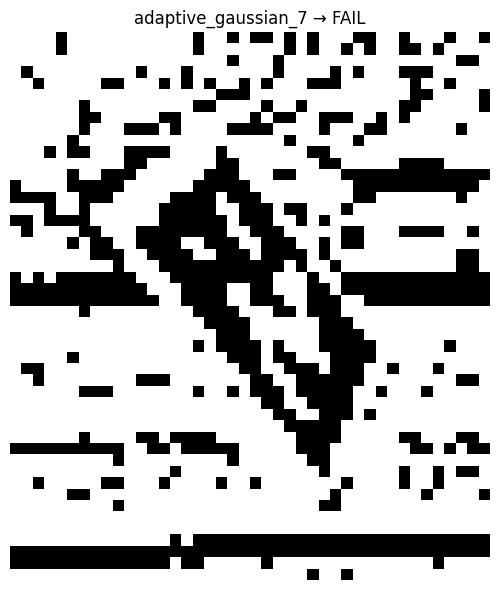

[43] adaptive_gaussian_11 | shape=(48, 42, 3) | success=False


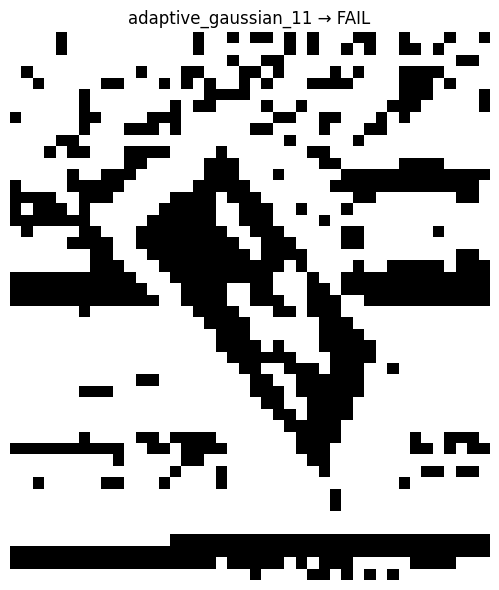

[44] adaptive_gaussian_15 | shape=(48, 42, 3) | success=False


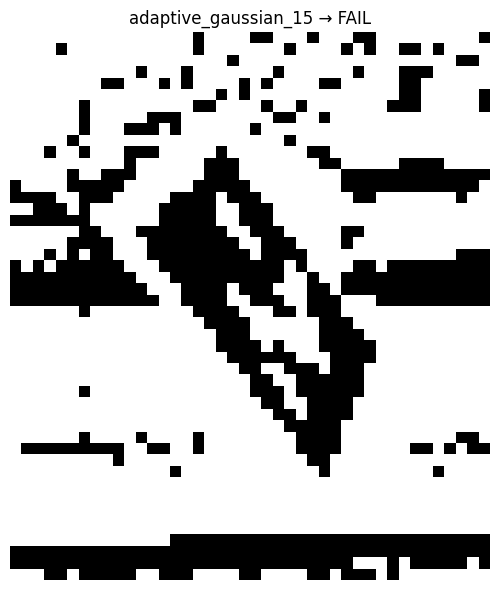

[45] adaptive_gaussian_2x_11 | shape=(96, 84, 3) | success=True


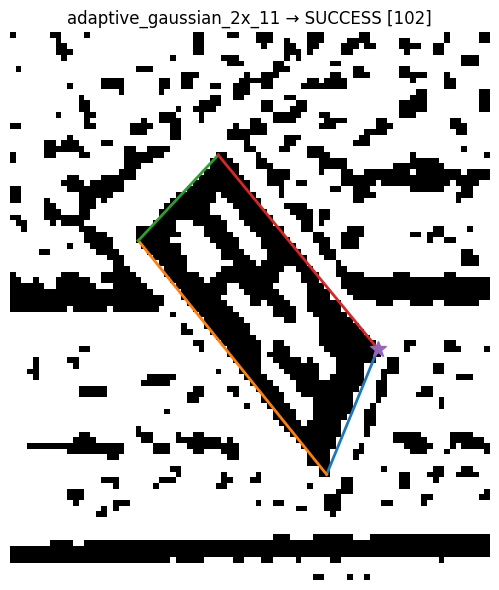

[46] adaptive_gaussian_2x_21 | shape=(96, 84, 3) | success=True


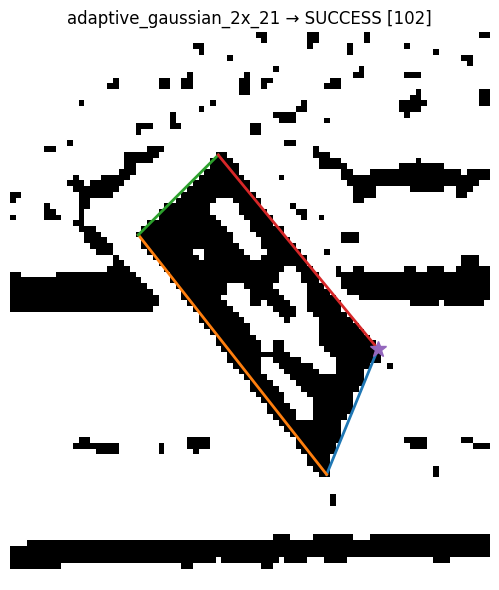

[47] adaptive_mean_11 | shape=(48, 42, 3) | success=False


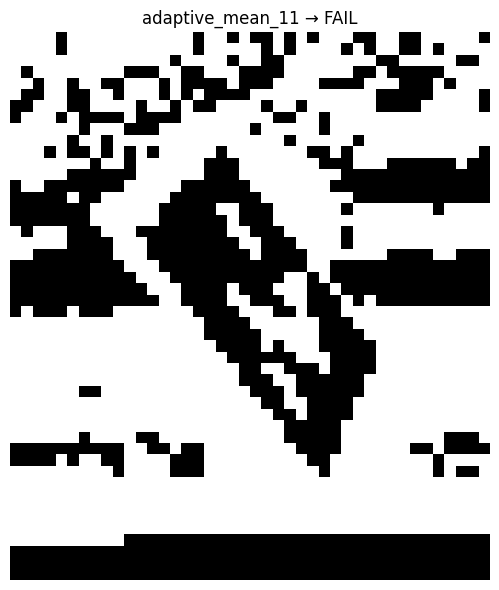

[48] adaptive_mean_15 | shape=(48, 42, 3) | success=False


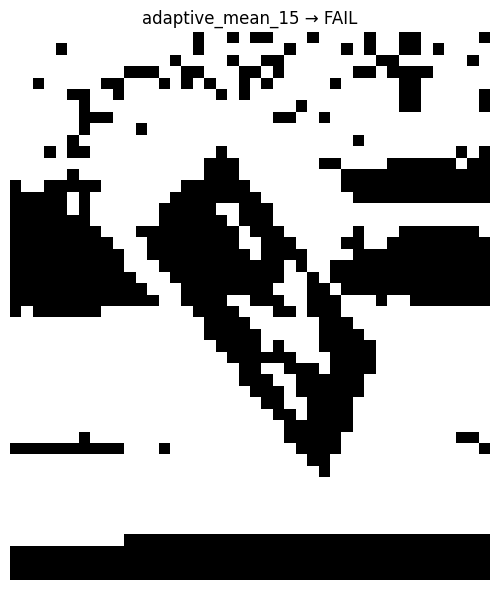

[49] adaptive_mean_2x_11 | shape=(96, 84, 3) | success=True


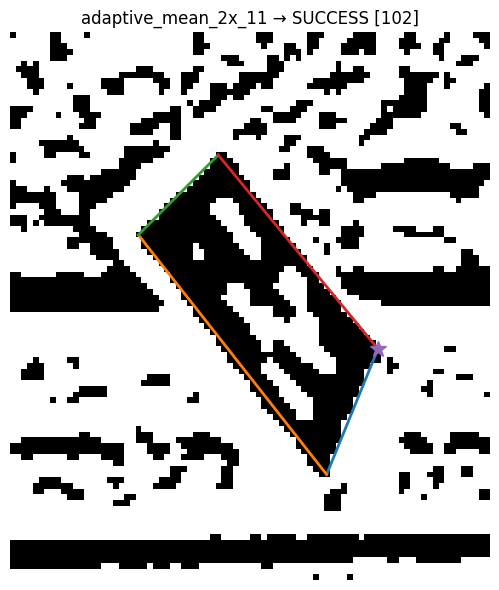

[50] median_otsu | shape=(48, 42, 3) | success=False


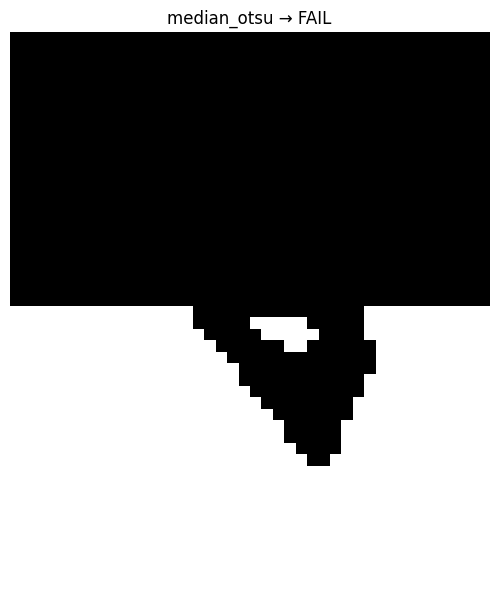

[51] median_otsu_2x | shape=(96, 84, 3) | success=False


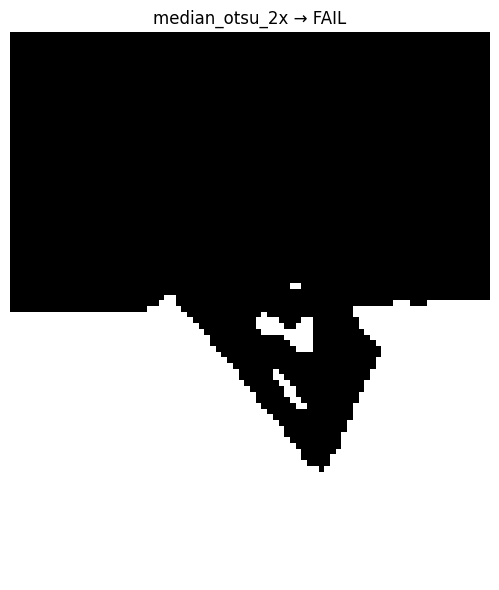

[52] clahe_otsu | shape=(48, 42, 3) | success=False


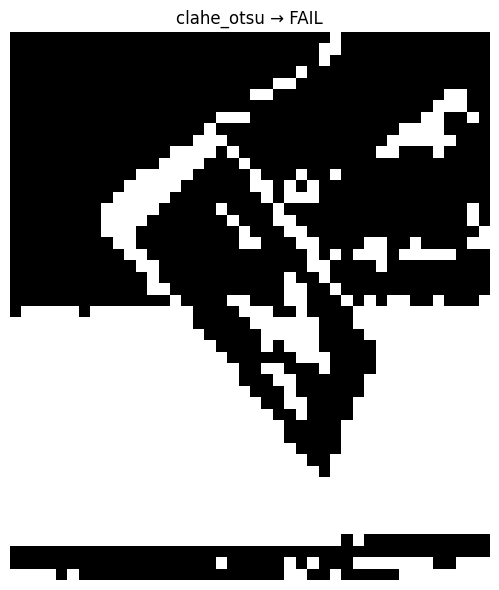

[53] clahe_otsu_2x | shape=(96, 84, 3) | success=False


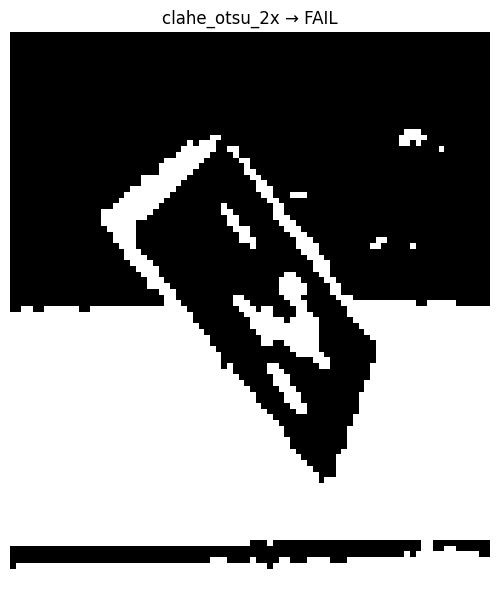

[54] clahe_strong_otsu | shape=(48, 42, 3) | success=False


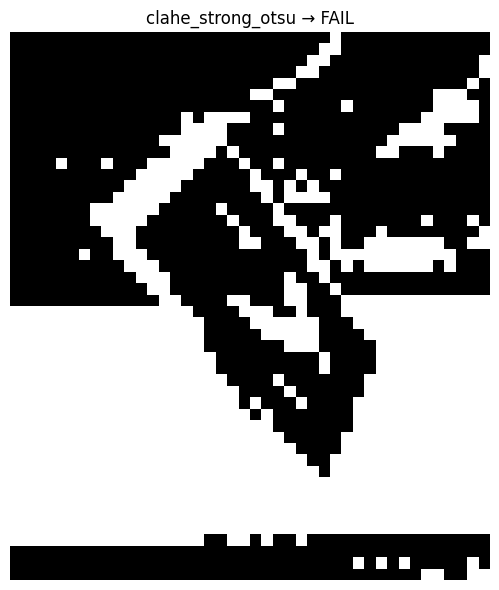

[55] equalize_otsu | shape=(48, 42, 3) | success=False


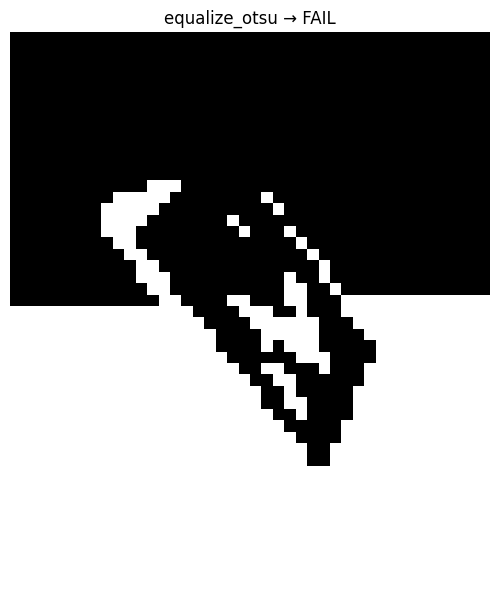

[56] equalize_otsu_2x | shape=(96, 84, 3) | success=False


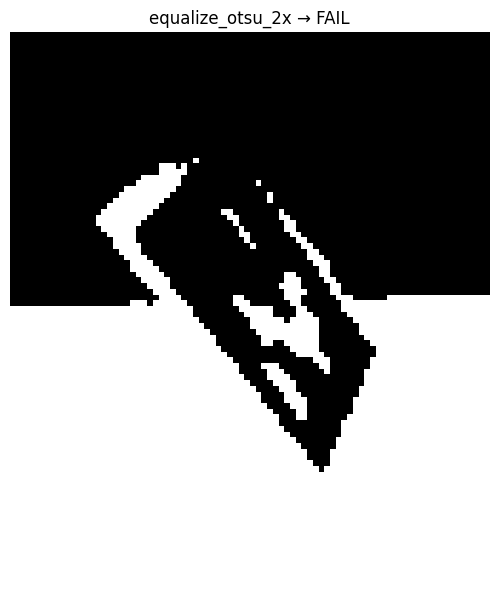

[57] dilation | shape=(48, 42, 3) | success=False


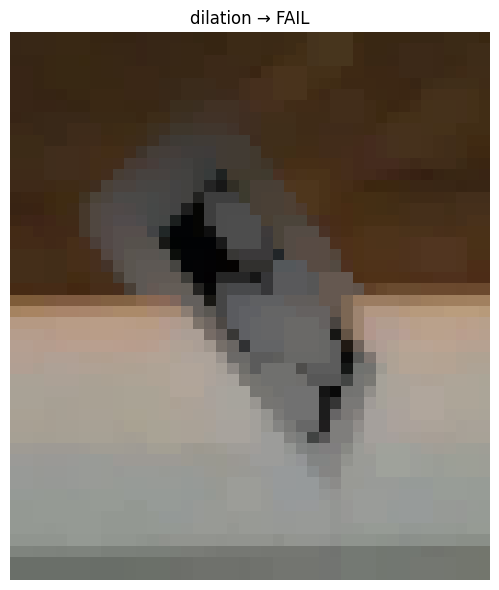

[58] erosion | shape=(48, 42, 3) | success=False


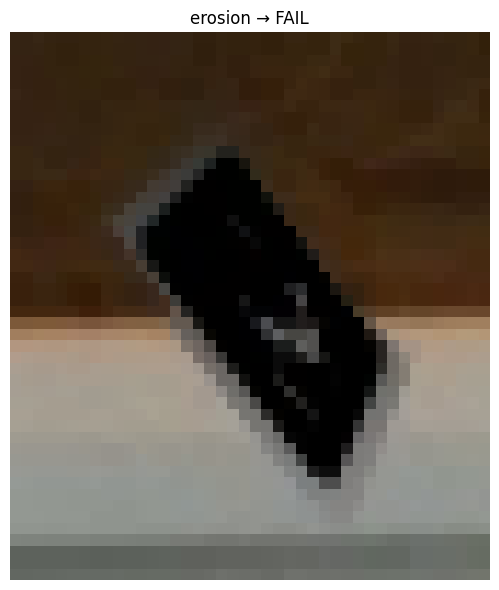

[59] dilation_2x | shape=(96, 84, 3) | success=False


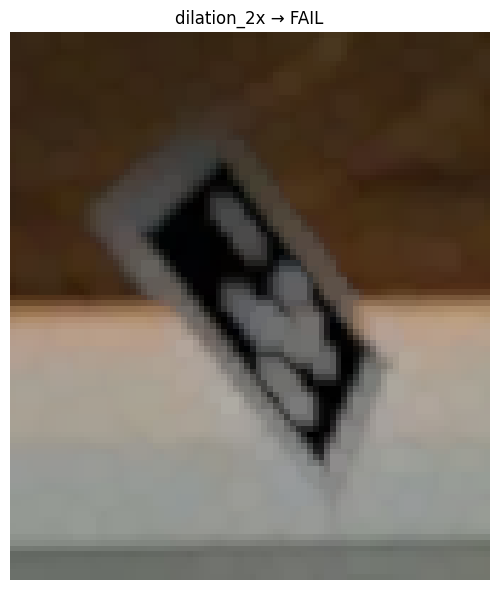

[60] erosion_2x | shape=(96, 84, 3) | success=False


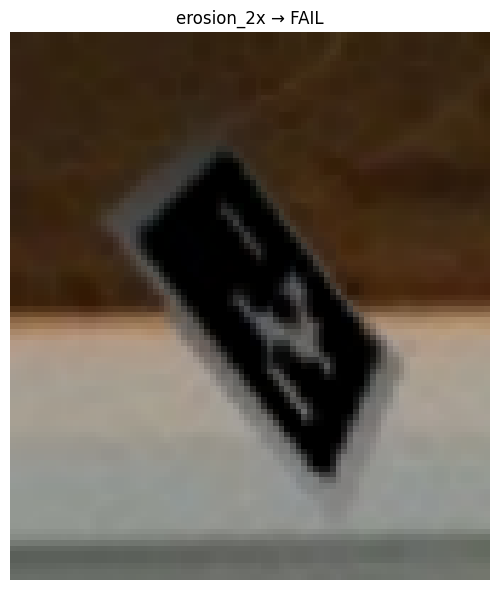

[61] dilate_otsu | shape=(48, 42, 3) | success=False


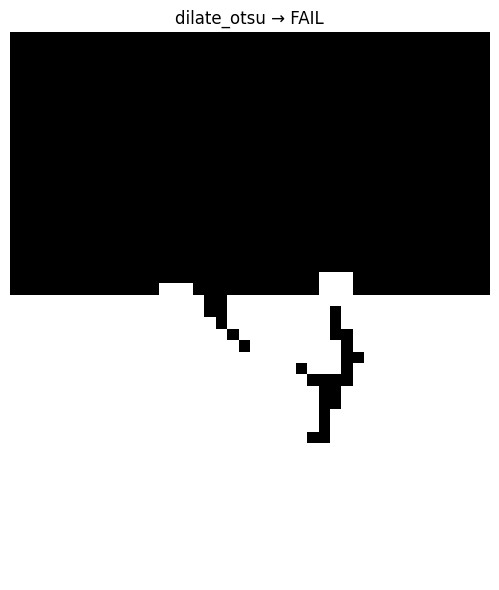

[62] dilate_otsu_2x | shape=(96, 84, 3) | success=False


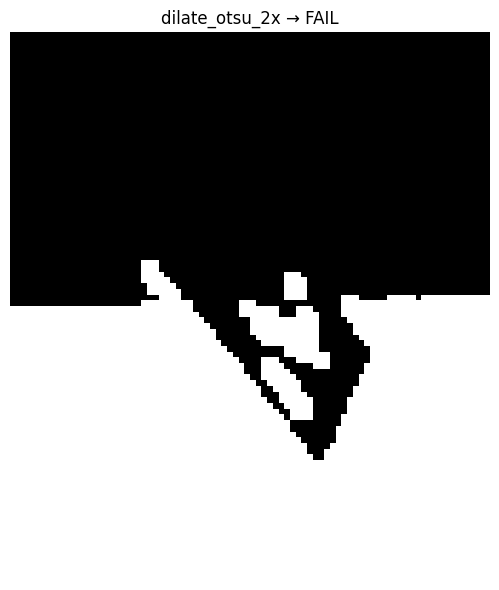

[63] invert | shape=(48, 42, 3) | success=False


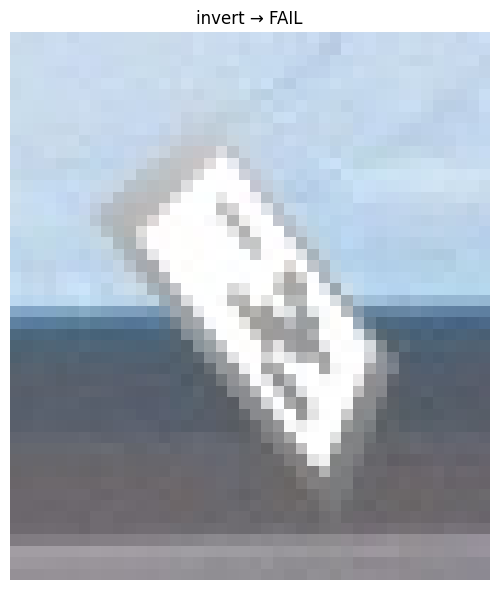

[64] invert_2x | shape=(96, 84, 3) | success=True


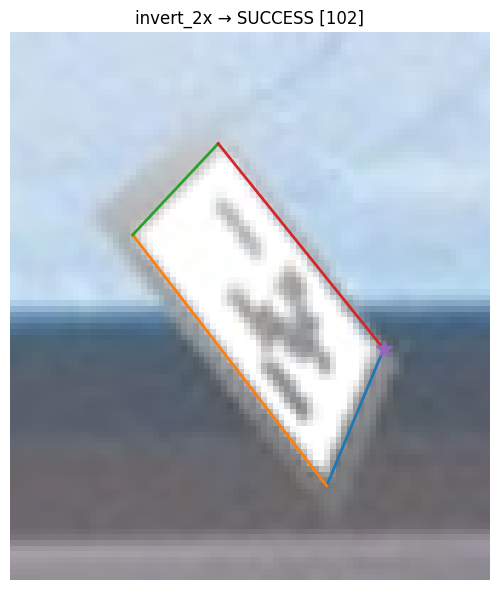

[65] invert_3x | shape=(240, 210, 3) | success=False


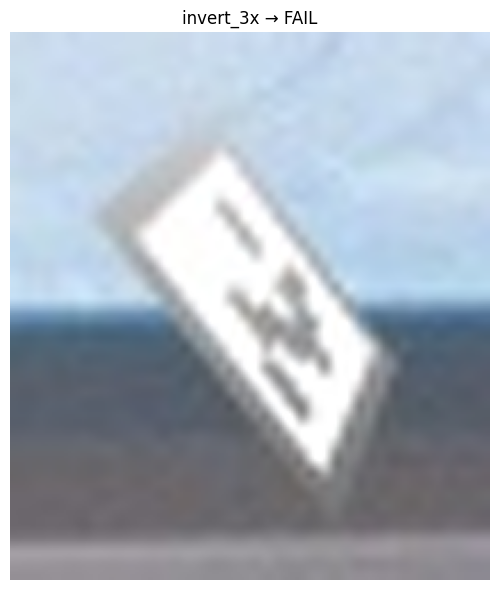

[66] invert_bright | shape=(48, 42, 3) | success=False


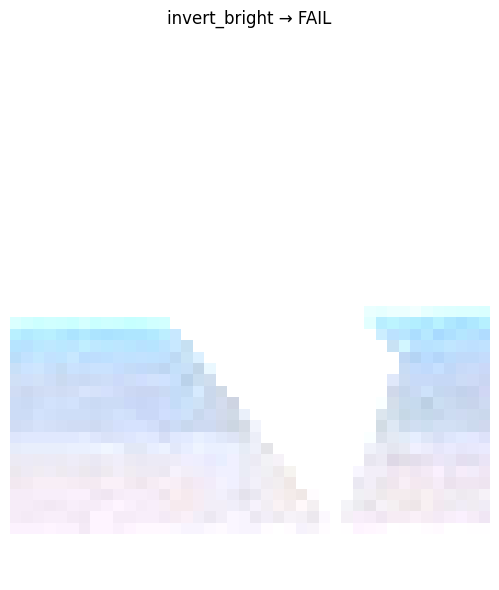

[67] invert_bright_2x | shape=(96, 84, 3) | success=False


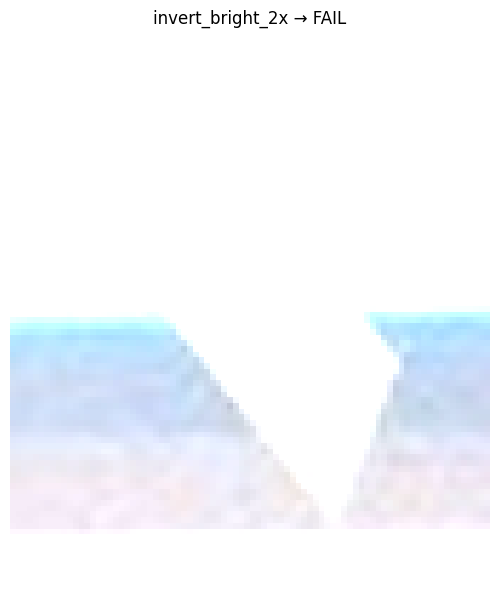

[68] invert_otsu | shape=(48, 42, 3) | success=False


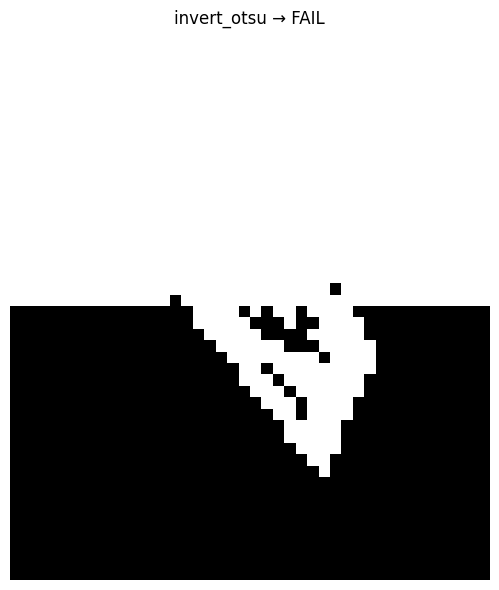

[69] invert_otsu_2x | shape=(96, 84, 3) | success=False


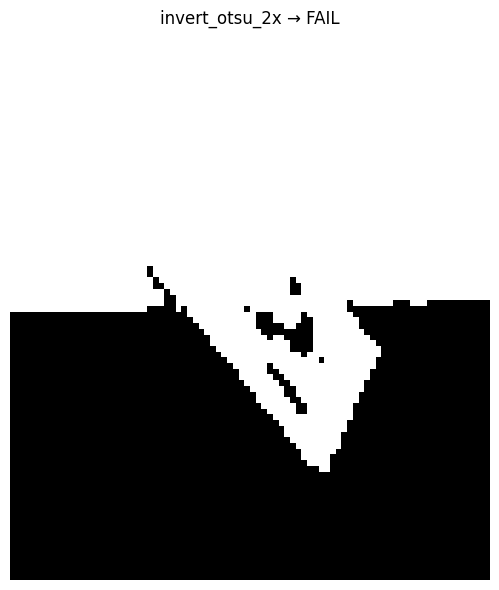

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from src.preprocess import generate_augmented_images, generate_augmented_images_strict
from src.detector import extract_candidates, filter_and_cluster_candidates
from src.postprocess import (
    load_cnn_model,
    is_real_marker_consistent,
    create_roi_with_padding,
    strict_detect_aruco_roi,
    strict_detect_aruco,
    order_corners,
    normalize_corners,
)
from src.preprocess import (
    aug_clahe_gamma_sharp,
    aug_dilation,
    aug_erosion,
)


# =========================================================
# BUILD ROI VARIANTS (GIỐNG HỆT PIPELINE)
# =========================================================

def build_roi_variants(roi_bgr):
    h, w = roi_bgr.shape[:2]

    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)

    roi_2x = cv2.resize(
        roi_bgr,
        (w * 2, h * 2),
        interpolation=cv2.INTER_CUBIC
    )

    roi_3x = cv2.resize(
        roi_bgr,
        (w * 5, h * 5),
        interpolation=cv2.INTER_CUBIC
    )

    gray_2x = cv2.cvtColor(roi_2x, cv2.COLOR_BGR2GRAY)
    gray_3x = cv2.cvtColor(roi_3x, cv2.COLOR_BGR2GRAY)

    # =====================================================
    # SHARPEN HELPER
    # =====================================================
    sharp_gray = cv2.addWeighted(
        gray,
        1.5,
        cv2.GaussianBlur(gray, (0, 0), 1.0),
        -0.5,
        0
    )

    sharp_gray_2x = cv2.addWeighted(
        gray_2x,
        1.5,
        cv2.GaussianBlur(gray_2x, (0, 0), 1.0),
        -0.5,
        0
    )
    def to_bgr(g):
        return cv2.cvtColor(g, cv2.COLOR_GRAY2BGR)

    def gamma(g, val):
        return np.uint8(np.clip(
            np.power(g.astype(np.float32) / 255.0, 1.0 / val) * 255, 0, 255
        ))

    def clahe(g, clip, grid):
        return cv2.createCLAHE(clipLimit=clip, tileGridSize=(grid, grid)).apply(g)


    variants = [
    # =====================================================
    # NHÓM 1: UPSCALE
    # =====================================================
    ("original", roi_bgr, 1.0),
    ("upscale_2x", roi_2x, 2.0),
    ("upscale_3x", roi_3x, 3.0),

    # =====================================================
    # NHÓM 2: DENOISE
    # =====================================================
    ("median_blur_3", cv2.medianBlur(roi_bgr, 3), 1.0),
    ("median_blur_2x_3", cv2.medianBlur(roi_2x, 3), 2.0),
    ("median_blur_2x_5", cv2.medianBlur(roi_2x, 5), 2.0),
    ("median_blur_3x_3", cv2.medianBlur(roi_3x, 3), 3.0),
    ("gaussian_blur_2x_3", cv2.GaussianBlur(roi_2x, (3, 3), 0), 2.0),
    ("bilateral_bgr", cv2.bilateralFilter(roi_bgr, 5, 40, 40), 1.0),
    ("bilateral_2x", cv2.bilateralFilter(roi_2x, 7, 60, 60), 2.0),
    ("clahe_gamma_sharp", aug_clahe_gamma_sharp(roi_bgr), 1.0),

    # =====================================================
    # NHÓM 3: ẢNH QUÁ TỐI (GAMMA / SCALE / CLAHE)
    # =====================================================
    ("gamma_2", to_bgr(gamma(gray, 2.0)), 1.0),
    ("gamma_3", to_bgr(gamma(gray, 3.0)), 1.0),
    ("gamma_2x_2", to_bgr(gamma(gray_2x, 2.0)), 2.0),
    ("gamma_2x_3", to_bgr(gamma(gray_2x, 3.0)), 2.0),

    ("bright_a2_b30", cv2.convertScaleAbs(roi_bgr, alpha=2.0, beta=30), 1.0),
    ("bright_a25_b50", cv2.convertScaleAbs(roi_bgr, alpha=2.5, beta=50), 1.0),
    ("bright_a3_b80", cv2.convertScaleAbs(roi_bgr, alpha=3.0, beta=80), 1.0),

    ("bright_2x_a2_b30", cv2.convertScaleAbs(roi_2x, alpha=2.0, beta=30), 2.0),
    ("bright_2x_a25_b50", cv2.convertScaleAbs(roi_2x, alpha=2.5, beta=50), 2.0),
    ("bright_2x_a3_b80", cv2.convertScaleAbs(roi_2x, alpha=3.0, beta=80), 2.0),

    ("clahe_4_8", to_bgr(clahe(gray, 4.0, 8)), 1.0),
    ("clahe_8_4", to_bgr(clahe(gray, 8.0, 4)), 1.0),
    ("clahe_12_2", to_bgr(clahe(gray, 12.0, 2)), 1.0),

    ("clahe_2x_4_8", to_bgr(clahe(gray_2x, 4.0, 8)), 2.0),
    ("clahe_2x_8_4", to_bgr(clahe(gray_2x, 8.0, 4)), 2.0),

    ("equalize", to_bgr(cv2.equalizeHist(gray)), 1.0),
    ("equalize_2x", to_bgr(cv2.equalizeHist(gray_2x)), 2.0),

    ("clahe_gamma", to_bgr(gamma(clahe(gray, 8.0, 4), 2.0)), 1.0),
    ("clahe_gamma_2x", to_bgr(gamma(clahe(gray_2x, 8.0, 4), 2.0)), 2.0),

    # =====================================================
    # NHÓM 4: ẢNH QUÁ SÁNG / OVEREXPOSED
    # =====================================================
    ("dark_a04_b30", cv2.convertScaleAbs(roi_bgr, alpha=0.4, beta=-30), 1.0),
    ("dark_a05_b50", cv2.convertScaleAbs(roi_bgr, alpha=0.5, beta=-50), 1.0),
    ("dark_a06_b20", cv2.convertScaleAbs(roi_bgr, alpha=0.6, beta=-20), 1.0),

    ("dark_2x_a04_b30", cv2.convertScaleAbs(roi_2x, alpha=0.4, beta=-30), 2.0),
    ("dark_2x_a05_b50", cv2.convertScaleAbs(roi_2x, alpha=0.5, beta=-50), 2.0),

    ("gamma_light_05", to_bgr(gamma(gray, 0.5)), 1.0),
    ("gamma_light_04", to_bgr(gamma(gray, 0.4)), 1.0),
    ("gamma_light_2x_05", to_bgr(gamma(gray_2x, 0.5)), 2.0),

    # =====================================================
    # NHÓM 5: THRESHOLD THỦ CÔNG
    # =====================================================
    ("otsu", to_bgr(cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]), 1.0),
    ("otsu_2x", to_bgr(cv2.threshold(gray_2x, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]), 2.0),
    ("otsu_3x", to_bgr(cv2.threshold(gray_3x, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]), 3.0),

    ("adaptive_gaussian_7", to_bgr(cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 7, 2)), 1.0),
    ("adaptive_gaussian_11", to_bgr(cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)), 1.0),
    ("adaptive_gaussian_15", to_bgr(cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 3)), 1.0),

    ("adaptive_gaussian_2x_11", to_bgr(cv2.adaptiveThreshold(gray_2x, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)), 2.0),
    ("adaptive_gaussian_2x_21", to_bgr(cv2.adaptiveThreshold(gray_2x, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 4)), 2.0),

    ("adaptive_mean_11", to_bgr(cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)), 1.0),
    ("adaptive_mean_15", to_bgr(cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 15, 3)), 1.0),
    ("adaptive_mean_2x_11", to_bgr(cv2.adaptiveThreshold(gray_2x, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)), 2.0),

    ("median_otsu", to_bgr(cv2.threshold(cv2.medianBlur(gray, 3), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]), 1.0),
    ("median_otsu_2x", to_bgr(cv2.threshold(cv2.medianBlur(gray_2x, 3), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]), 2.0),

    ("clahe_otsu", to_bgr(cv2.threshold(clahe(gray, 4.0, 8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]), 1.0),
    ("clahe_otsu_2x", to_bgr(cv2.threshold(clahe(gray_2x, 4.0, 8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]), 2.0),

    ("clahe_strong_otsu", to_bgr(cv2.threshold(clahe(gray, 8.0, 4), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]), 1.0),

    ("equalize_otsu", to_bgr(cv2.threshold(cv2.equalizeHist(gray), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]), 1.0),
    ("equalize_otsu_2x", to_bgr(cv2.threshold(cv2.equalizeHist(gray_2x), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]), 2.0),

    # =====================================================
    # NHÓM 6: MORPHOLOGY
    # =====================================================
    ("dilation", aug_dilation(roi_bgr), 1.0),
    ("erosion", aug_erosion(roi_bgr), 1.0),
    ("dilation_2x", aug_dilation(roi_2x), 2.0),
    ("erosion_2x", aug_erosion(roi_2x), 2.0),

    ("dilate_otsu", to_bgr(cv2.dilate(
        cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1],
        np.ones((3, 3), np.uint8)
    )), 1.0),

    ("dilate_otsu_2x", to_bgr(cv2.dilate(
        cv2.threshold(gray_2x, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1],
        np.ones((3, 3), np.uint8)
    )), 2.0),

    # =====================================================
    # NHÓM 7: INVERT
    # =====================================================
    ("invert", cv2.bitwise_not(roi_bgr), 1.0),
    ("invert_2x", cv2.bitwise_not(roi_2x), 2.0),
    ("invert_3x", cv2.bitwise_not(roi_3x), 3.0),

    ("invert_bright", cv2.convertScaleAbs(cv2.bitwise_not(roi_bgr), alpha=2.0, beta=30), 1.0),
    ("invert_bright_2x", cv2.convertScaleAbs(cv2.bitwise_not(roi_2x), alpha=2.0, beta=30), 2.0),

    ("invert_otsu", to_bgr(cv2.threshold(
        cv2.cvtColor(cv2.bitwise_not(roi_bgr), cv2.COLOR_BGR2GRAY),
        0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]), 1.0),

    ("invert_otsu_2x", to_bgr(cv2.threshold(
        cv2.cvtColor(cv2.bitwise_not(roi_2x), cv2.COLOR_BGR2GRAY),
        0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]), 2.0),
]

    return variants


# =========================================================
# VISUALIZE PIPELINE STEP 2 + ROI VARIANTS
# =========================================================

def visualize_pipeline_candidates(
    image_path,
    model,
    target_x=None,
    target_y=None,
    radius=120,
    threshold=0.5,
    padding=17,
):
    image = cv2.imread(image_path)

    if image is None:
        print("Cannot load image")
        return

    aug_dict = generate_augmented_images(image)

    raw_candidates = extract_candidates(image, aug_dict)
    final_candidates = filter_and_cluster_candidates(raw_candidates)

    print(f"Total final candidates: {len(final_candidates)}")

    # filter gần GT
    if target_x is not None and target_y is not None:
        target = np.array([target_x, target_y])
        filtered = []

        for cand in final_candidates:
            dist = np.linalg.norm(
                cand["corners"][0] - target
            )

            if dist <= radius:
                filtered.append((dist, cand))

        filtered.sort(key=lambda x: x[0])
        final_candidates = [x[1] for x in filtered]

        print(
            f"Candidates near ({target_x}, {target_y}) = "
            f"{len(final_candidates)}"
        )

    if not final_candidates:
        print("No candidate found")
        return

    # =====================================================
    # LOOP CANDIDATES
    # =====================================================

    for idx, cand in enumerate(final_candidates):
        print("\n" + "=" * 80)
        print(f"Candidate #{idx + 1}")
        print(f"source = {cand['source']}")
        print(f"mapped top-left = {cand['corners'][0]}")
        print(f"raw top-left    = {cand['raw_corners'][0]}")

        # CNN giống pipeline mới
        is_real, prob = is_real_marker_consistent(
            model,
            image,
            cand,
            threshold=threshold
        )

        print(
            f"CNN prob = {prob:.4f} | "
            f"is_real = {is_real}"
        )

        if not is_real:
            print("Skip because CNN = FAKE")
            continue

        # ROI crop
        roi, offset_x, offset_y = create_roi_with_padding(
            image,
            cand["corners"],
            padding=padding
        )

        print(f"ROI shape = {roi.shape}")
        print(f"offset = ({offset_x}, {offset_y})")

        # =================================================
        # SHOW ROI RECT ON ORIGINAL
        # =================================================

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(14, 6)
        )

        img_show = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        axes[0].imshow(img_show)
        axes[0].set_title("Original Image")

        pts = normalize_corners(cand["corners"])

        for i in range(4):
            p1 = pts[i]
            p2 = pts[(i + 1) % 4]

            axes[0].plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                linewidth=2
            )

        # top-left candidate
        axes[0].plot(
            pts[0][0],
            pts[0][1],
            marker="*",
            markersize=12
        )

        # GT point
        if target_x is not None and target_y is not None:
            axes[0].plot(
                target_x,
                target_y,
                marker="o",
                markersize=10
            )

        # ROI rectangle
        x1 = offset_x
        y1 = offset_y
        x2 = offset_x + roi.shape[1]
        y2 = offset_y + roi.shape[0]

        axes[0].plot(
            [x1, x2, x2, x1, x1],
            [y1, y1, y2, y2, y1],
            linewidth=2
        )

        axes[0].axis("off")

        # ROI image
        roi_show = cv2.cvtColor(
            roi,
            cv2.COLOR_BGR2RGB
        )

        axes[1].imshow(roi_show)
        axes[1].set_title("ROI")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

        # =================================================
        # VARIANTS DEBUG
        # =================================================

        variants = build_roi_variants(roi)

        first_success = False

        for vidx, (name, variant, scale_factor) in enumerate(variants):
            corners, ids = strict_detect_aruco_roi(
                variant
            )

            success = ids is not None

            print(
                f"[{vidx+1}] {name} | "
                f"shape={variant.shape} | "
                f"success={success}"
            )

            plt.figure(figsize=(6, 6))

            variant_show = cv2.cvtColor(
                variant,
                cv2.COLOR_BGR2RGB
            )

            plt.imshow(variant_show)

            title = name

            if success:
                ids_here = [
                    int(x[0]) for x in ids
                ]

                title += f" → SUCCESS {ids_here}"

                for mc in corners:
                    pts2 = mc[0]

                    for i in range(4):
                        p1 = pts2[i]
                        p2 = pts2[(i + 1) % 4]

                        plt.plot(
                            [p1[0], p2[0]],
                            [p1[1], p2[1]],
                            linewidth=2
                        )

                    plt.plot(
                        pts2[0][0],
                        pts2[0][1],
                        marker="*",
                        markersize=12
                    )

                if not first_success:
                    print(
                        f"FINAL DETECT SUCCESS "
                        f"from variant: {name}"
                    )
                    first_success = True

            else:
                title += " → FAIL"

            plt.title(title)
            plt.axis("off")
            plt.tight_layout()
            plt.show()

        if not first_success:
            print("FINAL DETECT FAIL")


# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":
    MODEL_PATH = "models/aruco_classifier_model_epoch50.keras"
    TEST_IMAGE = "data/aruco_data/train/000000000089.jpg"

    cnn_model = load_cnn_model(MODEL_PATH)

    visualize_pipeline_candidates(
        image_path=TEST_IMAGE,
        model=cnn_model,
        target_x=273.434,
        target_y=321.559,
        radius=5,
        threshold=0.1,
        padding=11,
    )